In [ ]:
# ============================================================================
# ENVIRONMENT SETUP & PACKAGE INSTALLATION
# ============================================================================
!pip install rdkit
!pip install jarvis-tools
!pip install pymatgen
!pip install pyvista
!apt-get update
!apt-get install -qq xvfb libgl1-mesa-glx

!pip install hvplot
!pip install mendeleev
!pip install dask
!pip install ase

import os
import sys
import glob
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib as mpl
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d import Axes3D

import networkx as nx
from rdkit import Chem
from rdkit.Chem import rdDetermineBonds
from rdkit.Chem import rdMolTransforms # <-- Added for Dihedral Math

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import scipy.signal as sig
import scipy.fft as fft
import scipy.ndimage as ndimg
from scipy.spatial import ConvexHull, Delaunay

from pymatgen.util.coord import *
from pymatgen.core import Structure as st
from pymatgen.core.operations import *
from pymatgen.core import *
from pymatgen.symmetry.analyzer import *
from pymatgen.transformations.standard_transformations import *
from pymatgen.analysis.local_env import *
from pymatgen.io.xyz import XYZ
from google.colab import drive

# ============================================================================
# DIRECTORY MOUNTING & DIAGNOSTICS
# ============================================================================
DIR='/content/drive'
drive.mount(DIR, force_remount=True)

HOME = os.path.join(DIR, 'MyDrive')
BASE_DIR = os.path.join(HOME, "NRL_Review")
INPUT_DIR = os.path.join(BASE_DIR, "ALLxyz")
SAVE_DIR = os.path.join(BASE_DIR, "Allplots")
SUBFOLDERS = ['nAcids', 'PFOA', 'PFOS', 'PFHA', 'PFHS', 'PFSA', 'FTOH', 'nAcidsNew']

print("\n--- DIRECTORY CHECK ---")
print(f"Target Input Directory: {INPUT_DIR}")
if not os.path.exists(INPUT_DIR):
    print(f"CRITICAL WARNING: The folder '{INPUT_DIR}' does not exist! Please check your Google Drive path spelling.")
else:
    print("Input Directory Found.")

# Clear out nested directories to ensure clean output for the strict plot rule
os.makedirs(SAVE_DIR, exist_ok=True)
for sub in SUBFOLDERS:
    os.makedirs(os.path.join(SAVE_DIR, sub), exist_ok=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 43.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 2.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.4/883.4 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 55.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 69.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.5/962.5 kB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 7.0 MB/s eta 0:00:00
  Created wh

/tmp/ipykernel_14539/2741229187.py:50: DeprecationWarning: This module has been moved to the pymatgen.core.local_env module. This stub will be removed v2027.1. 
  from pymatgen.analysis.local_env import *


Mounted at /content/drive

--- DIRECTORY CHECK ---
Target Input Directory: /content/drive/MyDrive/NRL_Review/ALLxyz
Input Directory Found.


In [ ]:


# ============================================================================
# PART 1: MATH, BACKBONE & DIHEDRAL EXTRACTION
# ============================================================================

def get_sorted_backbone_coords(filepath):
    with open(filepath, 'r') as f:
        block = f.read()
    mol = Chem.rdmolfiles.MolFromXYZBlock(block)
    if mol is None: return None, None, None, "RDKit MolFromXYZBlock failed to parse."

    try:
        rdDetermineBonds.DetermineConnectivity(mol)
        rdDetermineBonds.DetermineBondOrders(mol)
        Chem.SanitizeMol(mol)
    except Exception as e:
        return None, None, None, f"RDKit Bond Determination failed: {e}"

    atoms = [atom.GetSymbol() for atom in mol.GetAtoms()]
    carbon_indices = [i for i, a in enumerate(atoms) if a == 'C']

    G = nx.Graph()
    for bond in mol.GetBonds():
        G.add_edge(bond.GetBeginAtomIdx(), bond.GetEndAtomIdx())

    subgraph = G.subgraph(carbon_indices)
    longest_path = []

    for i in carbon_indices:
        for j in carbon_indices:
            if i >= j: continue
            try:
                path = nx.shortest_path(subgraph, i, j)
                if len(path) > len(longest_path):
                    longest_path = path
            except nx.NetworkXNoPath:
                continue

    if not longest_path: return np.array([]), None, None, "No carbon backbone path found."

    tail_carbon = longest_path[-1]
    neighbors = list(G.neighbors(tail_carbon))
    has_oxygen = any(atoms[n] == 'O' for n in neighbors)

    if not has_oxygen:
        head_carbon = longest_path[0]
        head_neighbors = list(G.neighbors(head_carbon))
        if any(atoms[n] == 'O' for n in head_neighbors):
            longest_path = list(reversed(longest_path))

    conf = mol.GetConformer()
    sorted_coords = []
    for idx in longest_path:
        pos = conf.GetAtomPosition(idx)
        sorted_coords.append([pos.x, pos.y, pos.z])

    return np.array(sorted_coords), mol, longest_path, "Success"

def get_fccf_dihedrals(mol, backbone_indices):
    """Calculates every absolute F-C-C-F dihedral angle down the backbone."""
    conf = mol.GetConformer()
    dihedrals = []

    # Iterate through consecutive C-C bonds in the canonical backbone
    for i in range(len(backbone_indices) - 1):
        c1_idx = backbone_indices[i]
        c2_idx = backbone_indices[i+1]

        c1_atom = mol.GetAtomWithIdx(c1_idx)
        c2_atom = mol.GetAtomWithIdx(c2_idx)

        # Find all Fluorine neighbors for each carbon
        f1_neighbors = [n.GetIdx() for n in c1_atom.GetNeighbors() if n.GetSymbol() == 'F']
        f2_neighbors = [n.GetIdx() for n in c2_atom.GetNeighbors() if n.GetSymbol() == 'F']

        # Calculate cross-combinations (e.g. 2 F's * 3 F's = 6 angles)
        for f1 in f1_neighbors:
            for f2 in f2_neighbors:
                angle = abs(rdMolTransforms.GetDihedralDeg(conf, f1, c1_idx, c2_idx, f2))
                dihedrals.append(angle)

    return dihedrals

def get_cumulative_pc_angles(pc_coords):
    angles = []
    for i in range(1, len(pc_coords) - 1):
        v1 = pc_coords[i - 1] - pc_coords[i]
        v2 = pc_coords[i + 1] - pc_coords[i]
        n1, n2 = np.linalg.norm(v1), np.linalg.norm(v2)
        if n1 == 0 or n2 == 0:
            angles.append(0.0)
            continue
        cosine_angle = np.clip(np.dot(v1, v2) / (n1 * n2), -1.0, 1.0)
        angles.append(np.degrees(np.arccos(cosine_angle)))
    cum_angles = np.cumsum(angles)
    avg_twist = np.mean(angles) if len(angles) > 0 else 0.0
    total_cum_twist = cum_angles[-1] if len(cum_angles) > 0 else 0.0
    return total_cum_twist, avg_twist

# ============================================================================
# PART 2: VOXELIZATION & AUTOCORRELATION (mol_analysis package -- Andrew)
# ============================================================================

# NOTE: mol_analysis is installed from the pfas_repo directory on Google Drive.
# The path mirrors the PFAS_reduced_andrew notebook convention.
ANDREW = os.path.join(HOME, 'PFAS_andrew')
PACKAGE = os.path.join(ANDREW, 'pfas_repo')
os.chdir(PACKAGE)
import subprocess
subprocess.run(['pip', 'install', '-e', '.', '-q'], check=True)

from mol_analysis.descriptors import voxelize_fast as voxelize_fast_mol
from mol_analysis.transforms import two_pt_stats


def voxelize_carbon_backbone(backbone_coords, voxelized_domain=[97, 97, 97],
                              voxel_width=0.125, Rc=30.7):
    """
    Voxelize only the carbon backbone atoms using mol_analysis voxelize_fast.

    Parameters
    ----------
    backbone_coords : np.ndarray, shape (N, 3)
        3-D Cartesian coordinates of the sorted carbon backbone atoms.
    voxelized_domain : list
        Voxel grid dimensions [X, Y, Z].
    voxel_width : float
        Characteristic voxel side length in Angstroms.
    Rc : float
        Cutoff radius in Angstroms.

    Returns
    -------
    voxel_output : tuple  (voxel_array, combvec, min_max)
        voxel_array has shape (n_local_states, X, Y, Z).
    """
    g = backbone_coords              # (N, 3) coordinates
    a = ['C'] * len(backbone_coords) # all backbone atoms are carbon

    voxel_output = voxelize_fast_mol(
        g, a,
        local_states=['en_pauling', 'ionenergies'],
        max_deg=[1, 1],
        Rc=Rc,
        voxelized_domain=voxelized_domain,
        voxel_width=voxel_width,
        return_datamatrix=False
    )
    return voxel_output


def center_crop_3d(data, target_shape):
    """Centre-crop (or zero-pad) a 3-D array to target_shape."""
    if data.ndim != 3:
        raise ValueError(f"Input data must be a 3D numpy array, got {data.ndim}D")

    pad_width = []
    for i in range(3):
        if data.shape[i] < target_shape[i]:
            diff = target_shape[i] - data.shape[i]
            pad_width.append((diff // 2, diff - diff // 2))
        else:
            pad_width.append((0, 0))

    if any(p != (0, 0) for p in pad_width):
        data = np.pad(data, pad_width, mode='constant', constant_values=0)

    start_indices = [(data.shape[i] - target_shape[i]) // 2 for i in range(3)]
    end_indices   = [start_indices[i] + target_shape[i]     for i in range(3)]

    return data[start_indices[0]:end_indices[0],
                start_indices[1]:end_indices[1],
                start_indices[2]:end_indices[2]]


def compute_autocorrelation_features(voxel_output, crop_shape=(60, 60, 60)):
    """
    Compute two-point autocorrelation statistics and return a flattened,
    centre-cropped feature vector.

    Parameters
    ----------
    voxel_output : tuple
        Output of voxelize_carbon_backbone(); first element is the voxel array
        with shape (n_local_states, X, Y, Z).
    crop_shape : tuple
        Target shape for centre-cropping each correlation volume.
        Set to None to skip cropping.

    Returns
    -------
    spatial_features : np.ndarray, shape (n_features,)
        Concatenated, flattened (and optionally cropped) autocorrelation arrays.
    """
    M = voxel_output[0]          # (n_local_states, X, Y, Z)
    n_local_states = M.shape[0]

    all_corr_flat = []
    for l1 in range(n_local_states):
        for l2 in range(l1, n_local_states):   # upper triangle (auto + cross-corr)
            tpt = two_pt_stats(M, l1, l2, axes=(0, 1, 2))
            if crop_shape is not None:
                tpt = center_crop_3d(tpt, crop_shape)
            all_corr_flat.append(tpt.flatten())

    return np.concatenate(all_corr_flat)


# ============================================================================
# PART 3: MAIN PROCESSING LOOP
# ============================================================================

def process_all_data():
    all_data = []
    print("\n--- EXTRACTION AND COMPILATION ---")

    for subfolder in SUBFOLDERS:
        folder_path = os.path.join(INPUT_DIR, subfolder)
        search_pattern_1 = os.path.join(folder_path, "**", "*.[xX][yY][zZ]")
        search_pattern_2 = os.path.join(folder_path, "*.[xX][yY][zZ]")

        xyz_files = glob.glob(search_pattern_1, recursive=True)
        if not xyz_files:
            xyz_files = glob.glob(search_pattern_2)

        print(f"Scanning Directory: {folder_path} -> Found {len(xyz_files)} files.")

        for filepath in xyz_files:
            filename = os.path.basename(filepath)
            prefix = filename.replace('.xyz', '').replace('.XYZ', '')

            coords, mol, backbone_path, status_msg = get_sorted_backbone_coords(filepath)
            if coords is None or len(coords) < 3:
                continue

            # Local Twist & EVR Extraction (carbon backbone only)
            pca_local = PCA(n_components=3, svd_solver='full')
            scores = pca_local.fit_transform(coords)
            evr = pca_local.explained_variance_ratio_

            total_cum_twist, avg_twist = get_cumulative_pc_angles(scores[:, 1:3])

            # F-C-C-F Dihedral Extraction
            fccf_angles = get_fccf_dihedrals(mol, backbone_path)
            mean_fccf   = np.mean(fccf_angles)   if fccf_angles else 0.0
            median_fccf = np.median(fccf_angles) if fccf_angles else 0.0

            # Voxelization of carbon backbone using mol_analysis (Andrew's approach)
            try:
                voxel_output = voxelize_carbon_backbone(coords)
            except Exception as e:
                print(f"  [SKIP] Voxelization failed for {prefix}: {e}")
                continue

            # Two-point autocorrelation + centre-crop to spatial feature vector
            try:
                spatial_features = compute_autocorrelation_features(
                    voxel_output, crop_shape=(60, 60, 60)
                )
            except Exception as e:
                print(f"  [SKIP] Autocorrelation failed for {prefix}: {e}")
                continue

            num_carbon_atoms = len(coords)

            all_data.append({
                'prefix':    prefix,
                'subfolder': subfolder,
                'num_atoms': num_carbon_atoms,
                'local_evr': evr,
                'avg_twist': avg_twist,
                'cum_twist': total_cum_twist,
                'mean_fccf':   mean_fccf,
                'median_fccf': median_fccf,
                'spatial_features': spatial_features
            })

    return all_data

parsed_data = process_all_data()

# ============================================================================
# PART 4: PCA HELPER (Global and Local)
# ============================================================================

def apply_pca(data_subset):
    """Applies PCA to a subset of data and assigns 'pca_scores' to each dict. Returns explained variance."""
    if not data_subset: return None

    feature_matrix = np.array([d['spatial_features'] for d in data_subset])
    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(feature_matrix)

    n_components = min(10, len(scaled_features))
    pca = PCA(n_components=n_components)
    scores = pca.fit_transform(scaled_features)
    evr = pca.explained_variance_ratio_ * 100

    for i, d in enumerate(data_subset):
        d['pca_scores'] = scores[i]

    return evr

if parsed_data:
    print("\nPerforming standard scaling and unified PCA on compiled spatial correlations...")
    unified_evr = apply_pca(parsed_data)

# ============================================================================
# PART 5: UNIFIED PLOTTING ENGINE (Exactly 7 Plots, Strict Sorting/Coloring)
# ============================================================================

def generate_requested_7_plots(data_list, save_dir, suffix="", pca_evr=None):
    if not data_list: return

    # Sort strictly by (1) Number of Atoms, (2) Non-perfluoro before perfluoro (for nAcids), (3) Alphabetical
    sorted_data = sorted(data_list, key=lambda x: (
        x['num_atoms'],
        1 if 'perfluoro' in x['prefix'].lower() else 0,
        x['prefix'].lower()
    ))

    sorted_data = sorted(data_list, key=lambda x: (
        x['num_atoms'],
        1 if 'FC' in x['prefix'].upper() else 0,
        x['prefix'].lower()
    ))

    prefixes = [d['prefix'] for d in sorted_data]
    x = np.arange(len(prefixes))
    num_atoms_array = np.array([d['num_atoms'] for d in sorted_data])

    # Universal Colormap configuration strictly bounded by atom counts
    vmin = min(num_atoms_array)
    vmax = max(num_atoms_array)
    if vmin == vmax:
        vmin = 0 # Prevent singular normalization crashes
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    cmap = cm.viridis
    bar_colors = cmap(norm(num_atoms_array))

    # ---------------------------------------------------------
    # PLOT (i): Spatial-Corr PCA Layout (2x2 Multi-Plot)
    # ---------------------------------------------------------
    fig = plt.figure(figsize=(18, 16))
    fig.suptitle(f'Spatial Correlation PCA Projections {suffix}', fontsize=16)

    evr_labels = ["", "", ""]
    if pca_evr is not None:
        for i in range(min(3, len(pca_evr))):
            evr_labels[i] = f"({pca_evr[i]:.1f}%)"

    pc1_scores = np.array([d['pca_scores'][0] if len(d['pca_scores']) > 0 else 0.0 for d in sorted_data])
    pc2_scores = np.array([d['pca_scores'][1] if len(d['pca_scores']) > 1 else 0.0 for d in sorted_data])
    pc3_scores = np.array([d['pca_scores'][2] if len(d['pca_scores']) > 2 else 0.0 for d in sorted_data])

    scatter_kwargs = {'c': num_atoms_array, 'cmap': cmap, 'norm': norm, 's': 120, 'edgecolor': 'k', 'alpha': 0.85}

    def add_labels_2d(ax, x_data, y_data):
        for i, txt in enumerate(prefixes):
            ax.annotate(txt, (x_data[i], y_data[i]), fontsize=9, xytext=(5, 5), textcoords='offset points')

    # Subplot 1: PC1 vs PC2
    ax1 = fig.add_subplot(2, 2, 1)
    sc1 = ax1.scatter(pc1_scores, pc2_scores, **scatter_kwargs)
    add_labels_2d(ax1, pc1_scores, pc2_scores)
    ax1.set_xlabel(f"PC1 {evr_labels[0]}".strip())
    ax1.set_ylabel(f"PC2 {evr_labels[1]}".strip())
    ax1.set_title("PC1 vs PC2 Projection")
    ax1.grid(True, linestyle='--', alpha=0.5)
    plt.colorbar(sc1, ax=ax1, label='Number of Carbon Atoms')

    # Subplot 2: PC2 vs PC3
    ax2 = fig.add_subplot(2, 2, 2)
    sc2 = ax2.scatter(pc2_scores, pc3_scores, **scatter_kwargs)
    add_labels_2d(ax2, pc2_scores, pc3_scores)
    ax2.set_xlabel(f"PC2 {evr_labels[1]}".strip())
    ax2.set_ylabel(f"PC3 {evr_labels[2]}".strip())
    ax2.set_title("PC2 vs PC3 Projection")
    ax2.grid(True, linestyle='--', alpha=0.5)
    plt.colorbar(sc2, ax=ax2, label='Number of Carbon Atoms')

    # Subplot 3: PC1 vs PC3
    ax3 = fig.add_subplot(2, 2, 3)
    sc3 = ax3.scatter(pc1_scores, pc3_scores, **scatter_kwargs)
    add_labels_2d(ax3, pc1_scores, pc3_scores)
    ax3.set_xlabel(f"PC1 {evr_labels[0]}".strip())
    ax3.set_ylabel(f"PC3 {evr_labels[2]}".strip())
    ax3.set_title("PC1 vs PC3 Projection")
    ax3.grid(True, linestyle='--', alpha=0.5)
    plt.colorbar(sc3, ax=ax3, label='Number of Carbon Atoms')

    # Subplot 4: 3D Scatter (PC1, PC2, PC3)
    ax4 = fig.add_subplot(2, 2, 4, projection='3d')
    sc4 = ax4.scatter(pc1_scores, pc2_scores, pc3_scores, **scatter_kwargs)
    ax4.set_xlabel(f"PC1 {evr_labels[0]}".strip())
    ax4.set_ylabel(f"PC2 {evr_labels[1]}".strip())
    ax4.set_zlabel(f"PC3 {evr_labels[2]}".strip())
    ax4.set_title("3D PCA Space")
    fig.colorbar(sc4, ax=ax4, label='Number of Carbon Atoms', pad=0.1)

    plt.tight_layout(rect=[0, 0.03, 1, 0.97])
    plt.savefig(os.path.join(save_dir, "1_Spatial_PCA_Scatter.png"), dpi=300)
    plt.close()

    # ---------------------------------------------------------
    # PLOT (ii): Average Twist
    # ---------------------------------------------------------
    fig, ax = plt.subplots(figsize=(max(10, len(prefixes)*0.4), 7))
    avg_twists = [d['avg_twist'] for d in sorted_data]

    ax.bar(x, avg_twists, color=bar_colors, edgecolor='k')
    ax.set_xticks(x); ax.set_xticklabels(prefixes, rotation=45, ha='right')
    ax.set_ylabel('Average Twist Angle (Degrees)')
    ax.set_title(f'Average Twist per Molecule {suffix}')
    plt.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label='Number of Carbon Atoms')
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "2_Average_Twist.png"), dpi=300)
    plt.close()

    # ---------------------------------------------------------
    # PLOT (iii): Cumulative Sum of Twist
    # ---------------------------------------------------------
    fig, ax = plt.subplots(figsize=(max(10, len(prefixes)*0.4), 7))
    cum_twists = [d['cum_twist'] for d in sorted_data]

    ax.bar(x, cum_twists, color=bar_colors, edgecolor='k')
    ax.set_xticks(x); ax.set_xticklabels(prefixes, rotation=45, ha='right')
    ax.set_ylabel('Cumulative Sum of Twist (Degrees)')
    ax.set_title(f'Cumulative Twist per Molecule {suffix}')
    plt.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label='Number of Carbon Atoms')
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "3_Cumulative_Twist.png"), dpi=300)
    plt.close()

    # ---------------------------------------------------------
    # PLOT (iv): PC123 Stacked Bar Chart (Local Backbone EVR)
    # ---------------------------------------------------------
    fig, ax = plt.subplots(figsize=(max(10, len(prefixes)*0.4), 7))
    pc1 = np.array([d['local_evr'][0] for d in sorted_data])
    pc2 = np.array([d['local_evr'][1] for d in sorted_data])
    pc3 = np.array([d['local_evr'][2] for d in sorted_data])

    ax.bar(x, pc1, label='PC1', color='#1f77b4', edgecolor='k')
    ax.bar(x, pc2, bottom=pc1, label='PC2', color='#ff7f0e', edgecolor='k')
    ax.bar(x, pc3, bottom=pc1+pc2, label='PC3', color='#2ca02c', edgecolor='k')

    ax.set_xticks(x); ax.set_xticklabels(prefixes, rotation=45, ha='right')
    ax.set_ylabel('Local Explained Variance Ratio')
    ax.set_title(f'Stacked PC1-PC3 Variance Ratio {suffix}')
    ax.legend(loc='best')
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "4_Stacked_PC123_Variance.png"), dpi=300)
    plt.close()

    # ---------------------------------------------------------
    # PLOT (v): PC3 Variance Only
    # ---------------------------------------------------------
    fig, ax = plt.subplots(figsize=(max(10, len(prefixes)*0.4), 7))

    ax.bar(x, pc3, color=bar_colors, edgecolor='k')
    ax.set_xticks(x); ax.set_xticklabels(prefixes, rotation=45, ha='right')
    ax.set_ylabel('PC3 Explained Variance Ratio')
    ax.set_title(f'PC3 Variance Only {suffix}')
    plt.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label='Number of Carbon Atoms')
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "5_PC3_Variance_Only.png"), dpi=300)
    plt.close()

    # ---------------------------------------------------------
    # PLOT (vi): Average Twist vs PC3
    # ---------------------------------------------------------
    fig, ax = plt.subplots(figsize=(10, 8))

    sc = ax.scatter(pc3, avg_twists, c=num_atoms_array, cmap=cmap, norm=norm, s=150, edgecolor='k', alpha=0.9)
    for i, txt in enumerate(prefixes):
        ax.annotate(txt, (pc3[i], avg_twists[i]), fontsize=8, xytext=(5, 5), textcoords='offset points')

    ax.set_xlabel('PC3 Explained Variance Ratio')
    ax.set_ylabel('Average Twist Angle (Degrees)')
    ax.set_title(f'Average Twist vs PC3 Variance {suffix}')
    ax.grid(True, linestyle='--', alpha=0.5)
    plt.colorbar(sc, ax=ax, label='Number of Carbon Atoms')
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "6_Avg_Twist_vs_PC3.png"), dpi=300)
    plt.close()

    # ---------------------------------------------------------
    # PLOT (vii): NEW - Grouped Mean & Median F-C-C-F Dihedrals
    # ---------------------------------------------------------
    fig, ax = plt.subplots(figsize=(max(10, len(prefixes)*0.5), 7))
    width = 0.35

    mean_dihedrals = [d['mean_fccf'] for d in sorted_data]
    median_dihedrals = [d['median_fccf'] for d in sorted_data]

    # We maintain the global colormap (bar_colors) for both, but use hatching to distinguish Median from Mean
    ax.bar(x - width/2, mean_dihedrals, width, color=bar_colors, edgecolor='k', label='Mean F-C-C-F')
    ax.bar(x + width/2, median_dihedrals, width, color=bar_colors, edgecolor='k', hatch='//', alpha=0.85, label='Median F-C-C-F')

    ax.set_xticks(x); ax.set_xticklabels(prefixes, rotation=45, ha='right')
    ax.set_ylabel('Absolute F-C-C-F Dihedral Angle (Degrees)')
    ax.set_title(f'Mean & Median F-C-C-F Dihedrals {suffix}')
    ax.legend(loc='best')
    plt.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label='Number of Carbon Atoms')
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "7_FCCF_Dihedrals.png"), dpi=300)
    plt.close()

# ============================================================================
# EXECUTION (Global AND Subfolder specific)
# ============================================================================

if parsed_data:
    print("\n--- GENERATING UNIFIED (ALL DATA) PLOTS ---")
    generate_requested_7_plots(parsed_data, SAVE_DIR, suffix="(All Data)", pca_evr=unified_evr)

    print("\n--- GENERATING SUBFOLDER-SPECIFIC PLOTS ---")
    for sub in SUBFOLDERS:
        sub_data = [d for d in parsed_data if d['subfolder'] == sub]
        if not sub_data: continue

        print(f"Generating isolated plots for {sub}...")
        sub_save_dir = os.path.join(SAVE_DIR, sub)

        sub_evr = apply_pca(sub_data)

        generate_requested_7_plots(sub_data, sub_save_dir, suffix=f"({sub})", pca_evr=sub_evr)

    print(f"\n[SUCCESS] Done! Exactly 7 target plots generated per folder perfectly organized in {SAVE_DIR}.")
else:
    print("\n[FAILED] No spatial features or XYZ backbone matches extracted.")


--- EXTRACTION AND COMPILATION ---
Scanning Directory: /content/drive/MyDrive/NRL_Review/ALLxyz/nAcids -> Found 18 files.
Scanning Directory: /content/drive/MyDrive/NRL_Review/ALLxyz/PFOA -> Found 6 files.
Scanning Directory: /content/drive/MyDrive/NRL_Review/ALLxyz/PFOS -> Found 7 files.
Scanning Directory: /content/drive/MyDrive/NRL_Review/ALLxyz/PFHA -> Found 4 files.
Scanning Directory: /content/drive/MyDrive/NRL_Review/ALLxyz/PFHS -> Found 5 files.
Scanning Directory: /content/drive/MyDrive/NRL_Review/ALLxyz/PFSA -> Found 8 files.
Scanning Directory: /content/drive/MyDrive/NRL_Review/ALLxyz/FTOH -> Found 15 files.
Scanning Directory: /content/drive/MyDrive/NRL_Review/ALLxyz/nAcidsNew -> Found 30 files.

Performing standard scaling and unified PCA on compiled spatial correlations...

--- GENERATING UNIFIED (ALL DATA) PLOTS ---

--- GENERATING SUBFOLDER-SPECIFIC PLOTS ---
Generating isolated plots for nAcids...
Generating isolated plots for PFOA...
Generating isolated plots for PFO


--- EXTRACTION AND COMPILATION ---
Scanning Directory: /content/drive/MyDrive/NRL_Review/ALLxyz/nAcids -> Found 18 files.
Scanning Directory: /content/drive/MyDrive/NRL_Review/ALLxyz/PFOA -> Found 6 files.
Scanning Directory: /content/drive/MyDrive/NRL_Review/ALLxyz/PFOS -> Found 7 files.
Scanning Directory: /content/drive/MyDrive/NRL_Review/ALLxyz/PFHA -> Found 4 files.
Scanning Directory: /content/drive/MyDrive/NRL_Review/ALLxyz/PFHS -> Found 5 files.
Scanning Directory: /content/drive/MyDrive/NRL_Review/ALLxyz/PFSA -> Found 8 files.
Scanning Directory: /content/drive/MyDrive/NRL_Review/ALLxyz/FTOH -> Found 15 files.
Scanning Directory: /content/drive/MyDrive/NRL_Review/ALLxyz/nAcidsNew -> Found 30 files.

Performing standard scaling and unified PCA on compiled spatial correlations...

--- GENERATING UNIFIED (ALL DATA) PLOTS ---

--- GENERATING SUBFOLDER-SPECIFIC PLOTS ---
Generating isolated plots for nAcids...
  Saved summary CSV -> /content/drive/MyDrive/NRL_Review/Allplots/nAcid

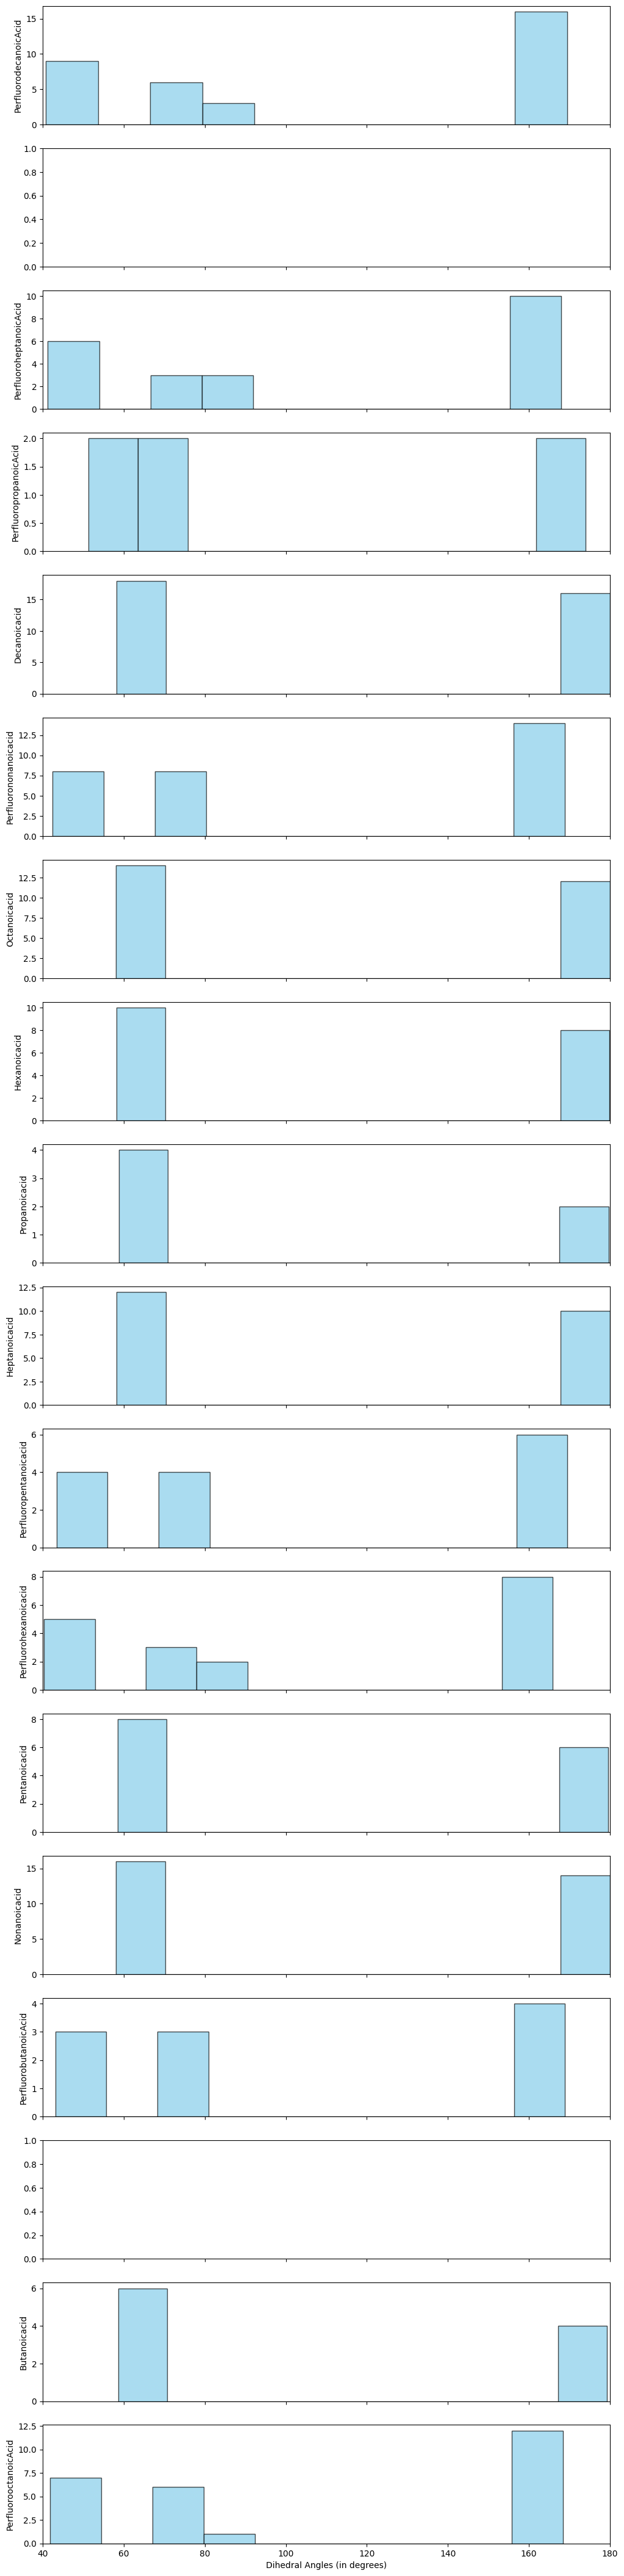

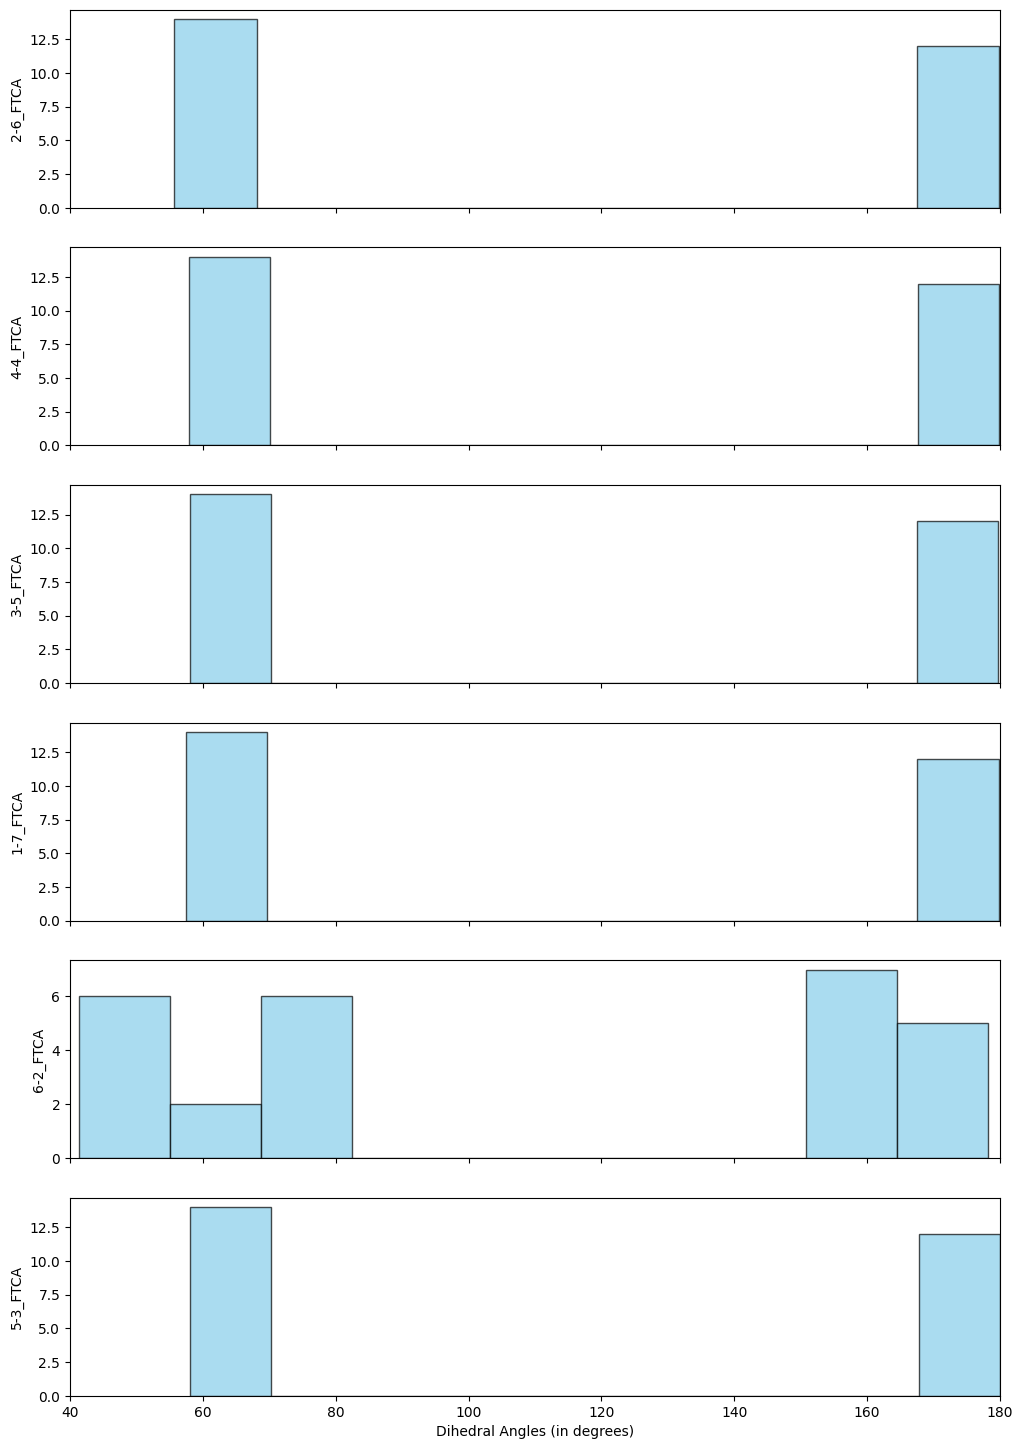

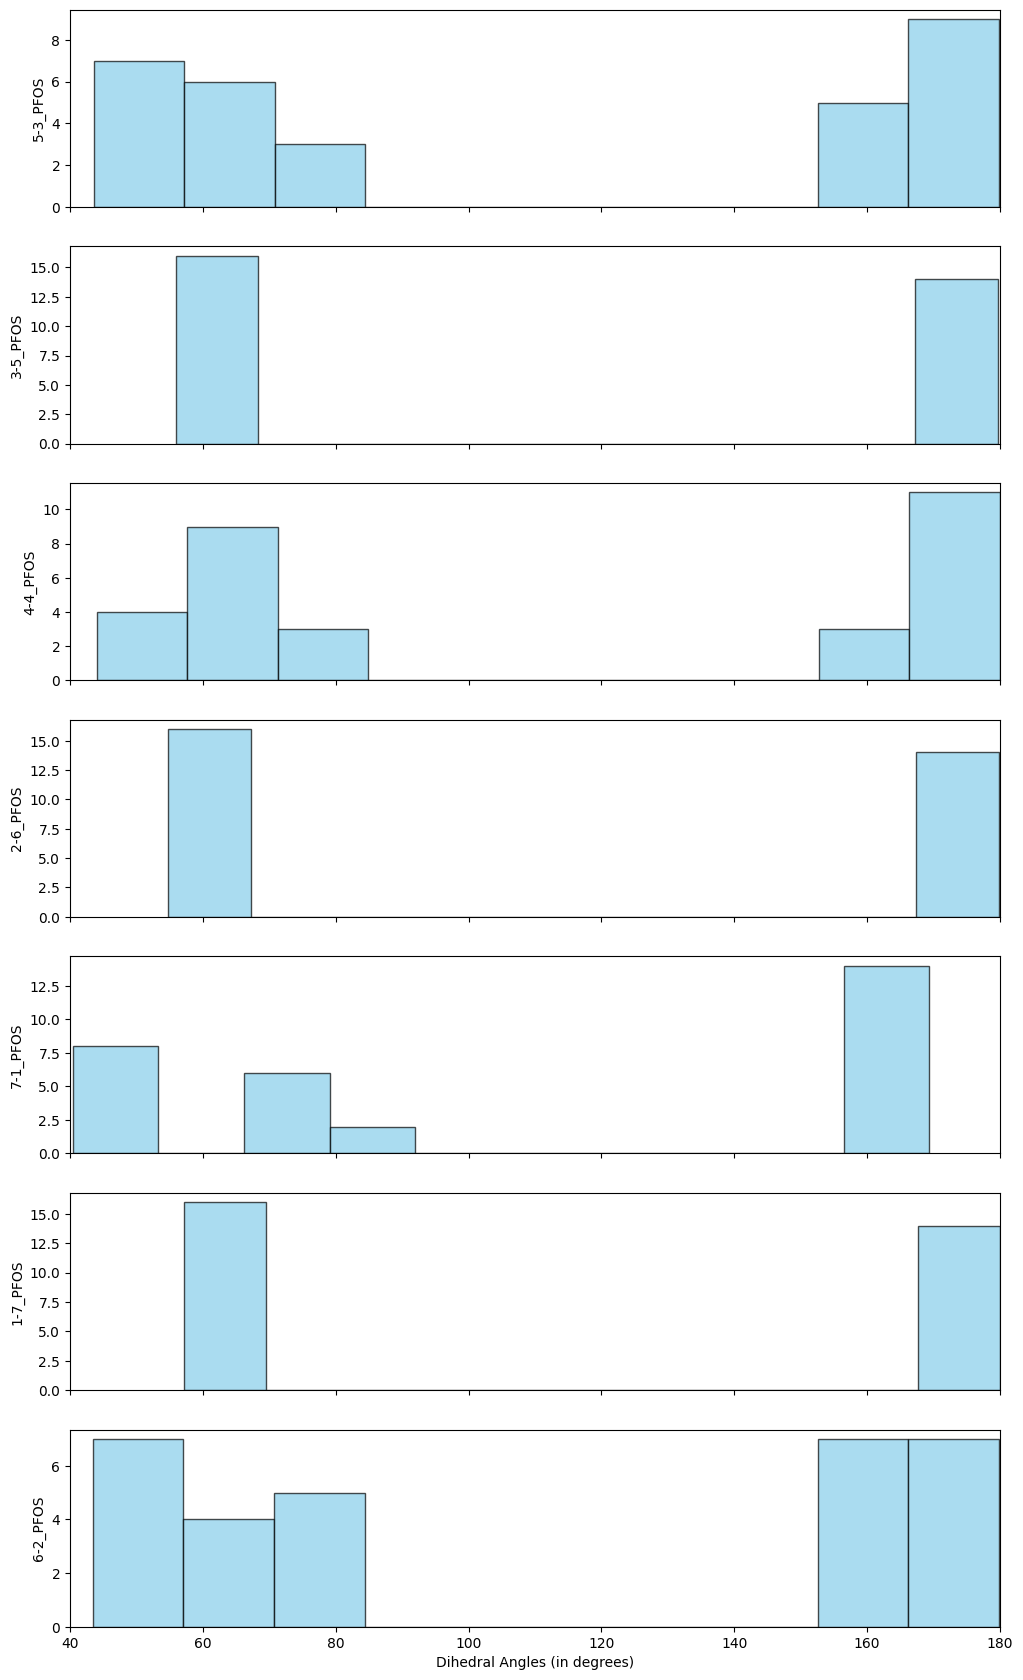

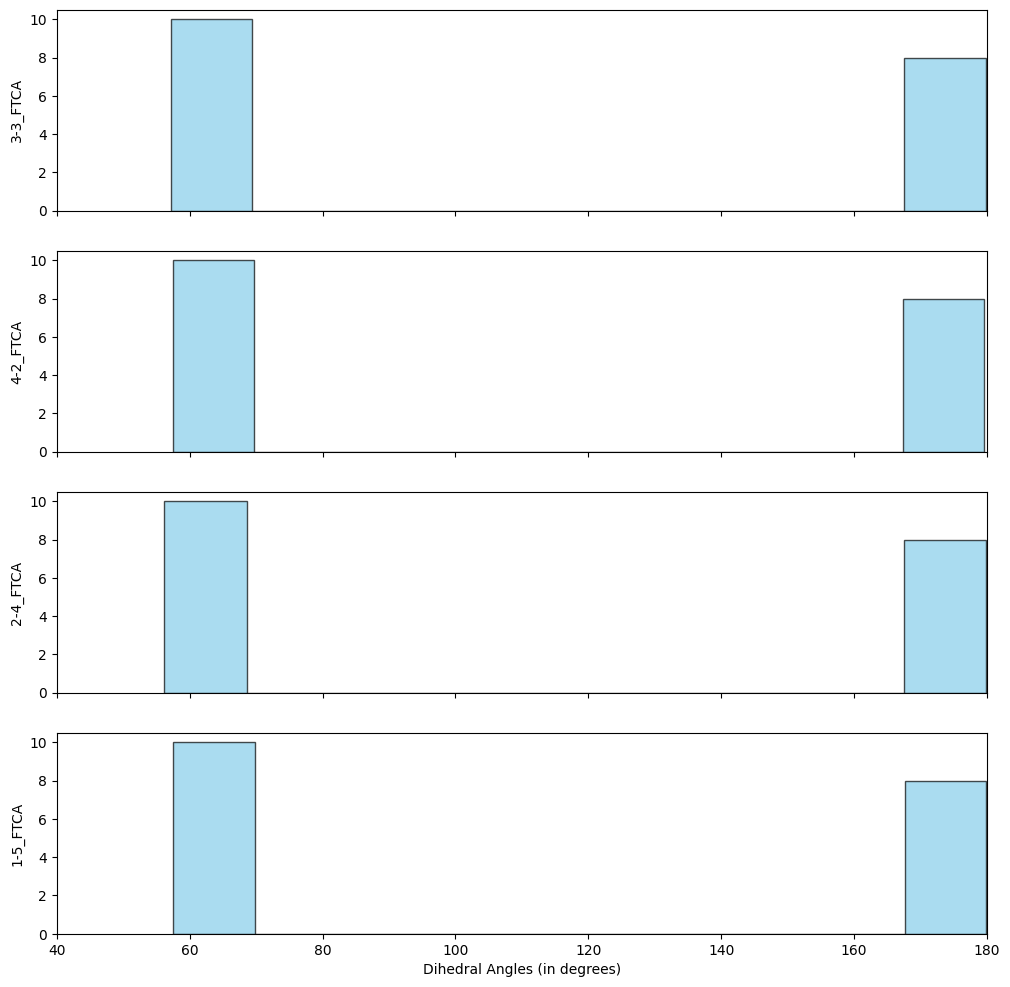

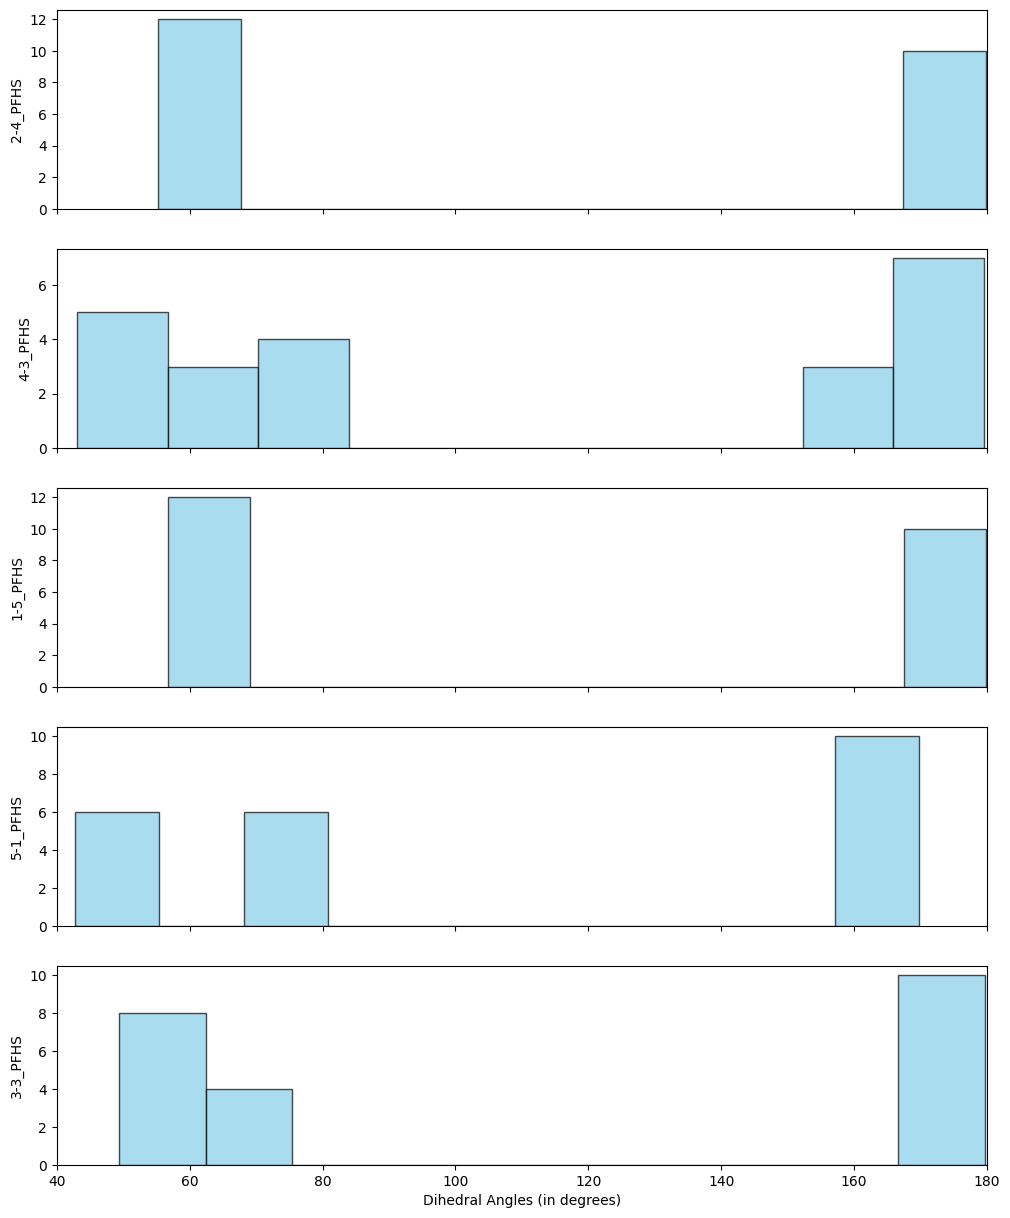

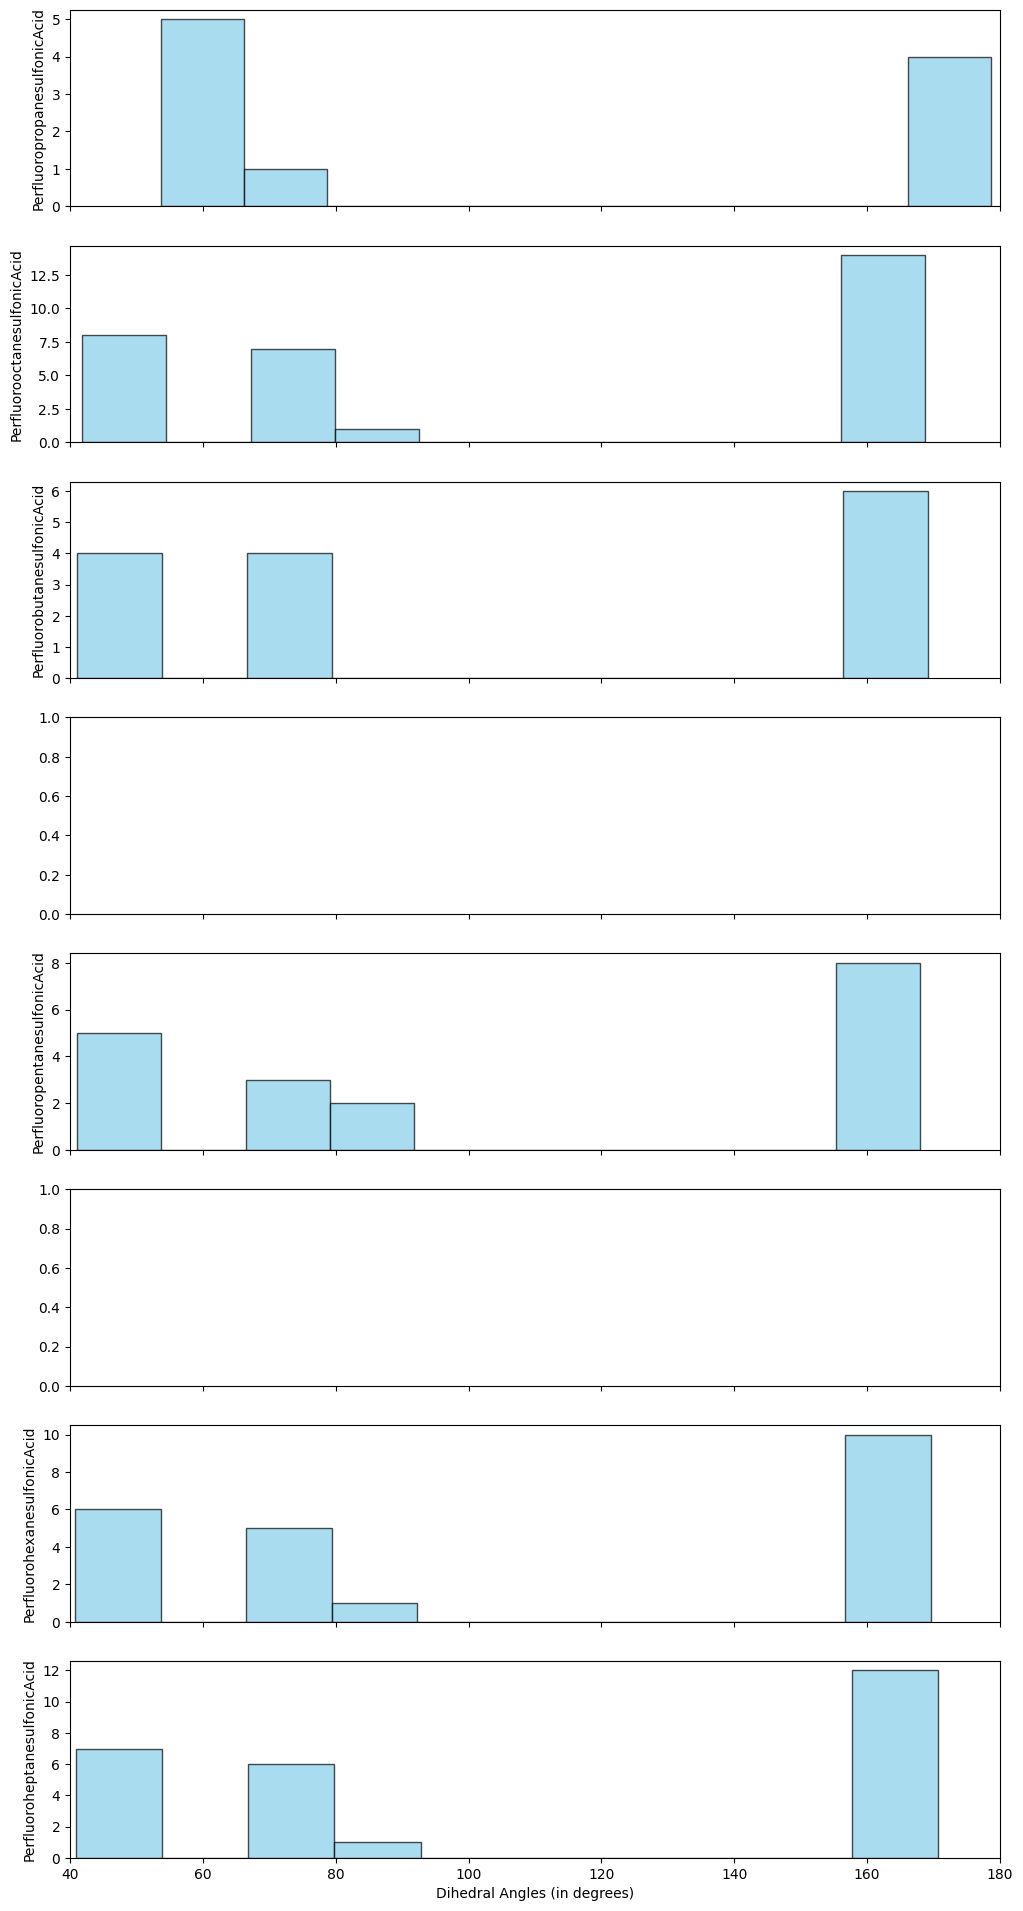

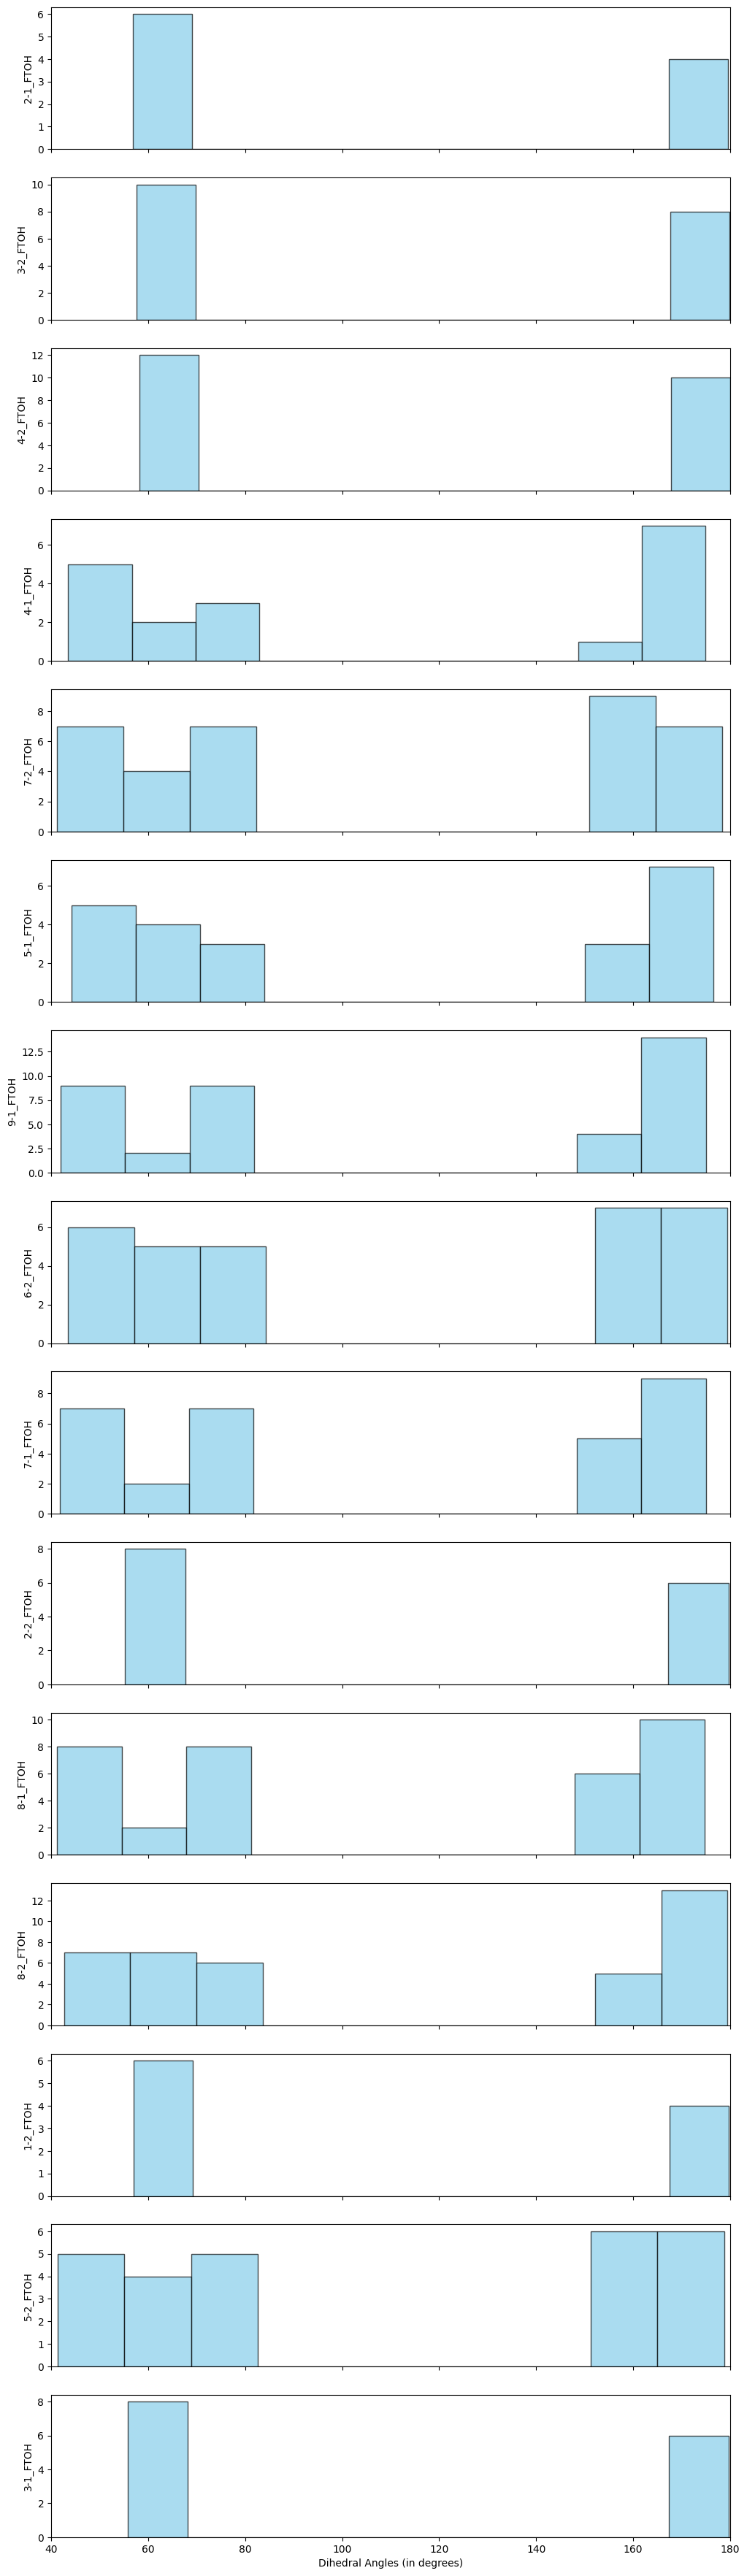

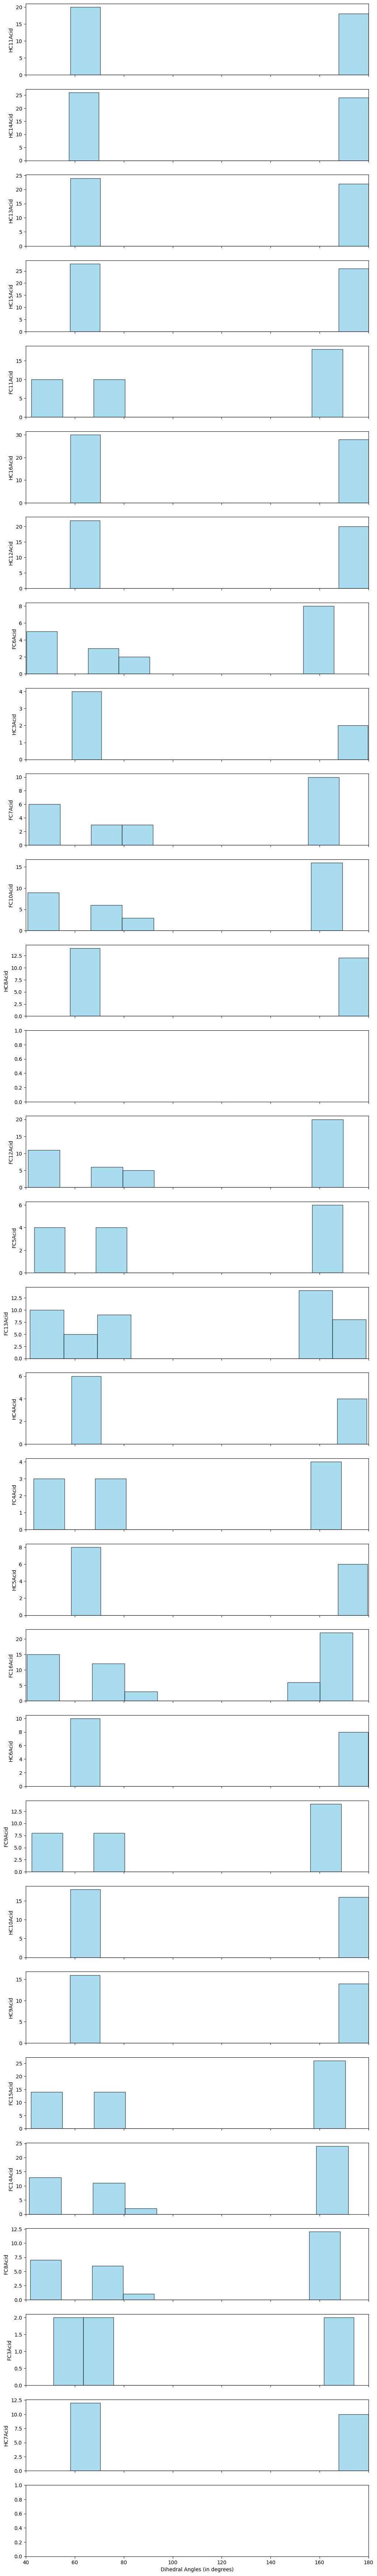

In [ ]:
def get_cumulative_pc_angles(pc_coords):
    angles = []
    for i in range(1, len(pc_coords) - 1):
        v1 = pc_coords[i - 1] - pc_coords[i]
        v2 = pc_coords[i + 1] - pc_coords[i]
        n1, n2 = np.linalg.norm(v1), np.linalg.norm(v2)
        if n1 == 0 or n2 == 0:
            angles.append(0.0)
            continue
        cosine_angle = np.clip(np.dot(v1, v2) / (n1 * n2), -1.0, 1.0)
        angles.append(np.degrees(np.arccos(cosine_angle)))
    cum_angles = np.cumsum(angles)
    avg_twist = np.mean(angles) if len(angles) > 0 else 0.0
    total_cum_twist = cum_angles[-1] if len(cum_angles) > 0 else 0.0
    return total_cum_twist, avg_twist

def get_sorted_backbone_coords(filepath):
    with open(filepath, 'r') as f:
        block = f.read()
    mol = Chem.rdmolfiles.MolFromXYZBlock(block)
    if mol is None: return None, None, None, "RDKit MolFromXYZBlock failed to parse."

    try:
        rdDetermineBonds.DetermineConnectivity(mol)
        rdDetermineBonds.DetermineBondOrders(mol)
        Chem.SanitizeMol(mol)
    except Exception as e:
        return None, None, None, f"RDKit Bond Determination failed: {e}"

    atoms = [atom.GetSymbol() for atom in mol.GetAtoms()]
    carbon_indices = [i for i, a in enumerate(atoms) if a == 'C']

    G = nx.Graph()
    for bond in mol.GetBonds():
        G.add_edge(bond.GetBeginAtomIdx(), bond.GetEndAtomIdx())

    subgraph = G.subgraph(carbon_indices)
    longest_path = []

    for i in carbon_indices:
        for j in carbon_indices:
            if i >= j: continue
            try:
                path = nx.shortest_path(subgraph, i, j)
                if len(path) > len(longest_path):
                    longest_path = path
            except nx.NetworkXNoPath:
                continue

    if not longest_path: return np.array([]), None, None, "No carbon backbone path found."

    tail_carbon = longest_path[-1]
    neighbors = list(G.neighbors(tail_carbon))
    has_oxygen = any(atoms[n] == 'O' for n in neighbors)

    if not has_oxygen:
        head_carbon = longest_path[0]
        head_neighbors = list(G.neighbors(head_carbon))
        if any(atoms[n] == 'O' for n in head_neighbors):
            longest_path = list(reversed(longest_path))

    conf = mol.GetConformer()
    sorted_coords = []
    for idx in longest_path:
        pos = conf.GetAtomPosition(idx)
        sorted_coords.append([pos.x, pos.y, pos.z])

    return np.array(sorted_coords), mol, longest_path, "Success"

def get_dihedrals(mol, backbone_indices):
    """Calculates absolute F-C-C-F dihedrals, or H-C-C-H if no fluorines are present."""
    conf = mol.GetConformer()
    dihedrals = []

    for i in range(len(backbone_indices) - 1):
        c1_idx = backbone_indices[i]
        c2_idx = backbone_indices[i+1]

        c1_atom = mol.GetAtomWithIdx(c1_idx)
        c2_atom = mol.GetAtomWithIdx(c2_idx)

        # Grab Fluorines. If list is empty, grab Hydrogens instead.
        f1_neighbors = [n.GetIdx() for n in c1_atom.GetNeighbors() if n.GetSymbol() == 'F']
        side_atoms_1 = f1_neighbors if f1_neighbors else [n.GetIdx() for n in c1_atom.GetNeighbors() if n.GetSymbol() == 'H']

        f2_neighbors = [n.GetIdx() for n in c2_atom.GetNeighbors() if n.GetSymbol() == 'F']
        side_atoms_2 = f2_neighbors if f2_neighbors else [n.GetIdx() for n in c2_atom.GetNeighbors() if n.GetSymbol() == 'H']

        # Calculate cross-combinations
        for a1 in side_atoms_1:
            for a2 in side_atoms_2:
                angle = abs(rdMolTransforms.GetDihedralDeg(conf, a1, c1_idx, c2_idx, a2))
                dihedrals.append(angle)

    return dihedrals

def deviation_from_planar(mean_dihedral_deg):
    """Computes deviation from planar arrangement: min(theta, 180 - theta)."""
    theta = mean_dihedral_deg
    return min(theta, 180.0 - theta)


# ============================================================================
# PART 2: VOXELIZATION & AUTOCORRELATION (mol_analysis package -- Andrew)
# ============================================================================

# NOTE: mol_analysis is installed from the pfas_repo directory on Google Drive.
# The path mirrors the PFAS_reduced_andrew notebook convention.
ANDREW = os.path.join(HOME, 'PFAS_andrew')
PACKAGE = os.path.join(ANDREW, 'pfas_repo')
os.chdir(PACKAGE)
import subprocess
subprocess.run(['pip', 'install', '-e', '.', '-q'], check=True)

from mol_analysis.descriptors import voxelize_fast as voxelize_fast_mol
from mol_analysis.transforms import two_pt_stats


def voxelize_carbon_backbone(backbone_coords, voxelized_domain=[97, 97, 97],
                              voxel_width=0.125, Rc=30.7):
    """
    Voxelize only the carbon backbone atoms using mol_analysis voxelize_fast.

    Parameters
    ----------
    backbone_coords : np.ndarray, shape (N, 3)
        3-D Cartesian coordinates of the sorted carbon backbone atoms.
    voxelized_domain : list
        Voxel grid dimensions [X, Y, Z].
    voxel_width : float
        Characteristic voxel side length in Angstroms.
    Rc : float
        Cutoff radius in Angstroms.

    Returns
    -------
    voxel_output : tuple  (voxel_array, combvec, min_max)
        voxel_array has shape (n_local_states, X, Y, Z).
    """
    g = backbone_coords              # (N, 3) coordinates
    a = ['C'] * len(backbone_coords) # all backbone atoms are carbon

    voxel_output = voxelize_fast_mol(
        g, a,
        local_states=['en_pauling', 'ionenergies'],
        max_deg=[1, 1],
        Rc=Rc,
        voxelized_domain=voxelized_domain,
        voxel_width=voxel_width,
        return_datamatrix=False
    )
    return voxel_output


def center_crop_3d(data, target_shape):
    """Centre-crop (or zero-pad) a 3-D array to target_shape."""
    if data.ndim != 3:
        raise ValueError(f"Input data must be a 3D numpy array, got {data.ndim}D")

    pad_width = []
    for i in range(3):
        if data.shape[i] < target_shape[i]:
            diff = target_shape[i] - data.shape[i]
            pad_width.append((diff // 2, diff - diff // 2))
        else:
            pad_width.append((0, 0))

    if any(p != (0, 0) for p in pad_width):
        data = np.pad(data, pad_width, mode='constant', constant_values=0)

    start_indices = [(data.shape[i] - target_shape[i]) // 2 for i in range(3)]
    end_indices   = [start_indices[i] + target_shape[i]     for i in range(3)]

    return data[start_indices[0]:end_indices[0],
                start_indices[1]:end_indices[1],
                start_indices[2]:end_indices[2]]


def compute_autocorrelation_features(voxel_output, crop_shape=(60, 60, 60)):
    """
    Compute two-point autocorrelation statistics and return a flattened,
    centre-cropped feature vector.

    Parameters
    ----------
    voxel_output : tuple
        Output of voxelize_carbon_backbone(); first element is the voxel array
        with shape (n_local_states, X, Y, Z).
    crop_shape : tuple
        Target shape for centre-cropping each correlation volume.
        Set to None to skip cropping.

    Returns
    -------
    spatial_features : np.ndarray, shape (n_features,)
        Concatenated, flattened (and optionally cropped) autocorrelation arrays.
    """
    M = voxel_output[0]          # (n_local_states, X, Y, Z)
    n_local_states = M.shape[0]

    all_corr_flat = []
    for l1 in range(n_local_states):
        for l2 in range(l1, n_local_states):   # upper triangle (auto + cross-corr)
            tpt = two_pt_stats(M, l1, l2, axes=(0, 1, 2))
            if crop_shape is not None:
                tpt = center_crop_3d(tpt, crop_shape)
            all_corr_flat.append(tpt.flatten())

    return np.concatenate(all_corr_flat)


# ============================================================================
# PART 3: MAIN PROCESSING LOOP
# ============================================================================

def process_all_data():
    all_data = []
    print("\n--- EXTRACTION AND COMPILATION ---")

    for subfolder in SUBFOLDERS:
        folder_path = os.path.join(INPUT_DIR, subfolder)
        search_pattern_1 = os.path.join(folder_path, "**", "*.[xX][yY][zZ]")
        search_pattern_2 = os.path.join(folder_path, "*.[xX][yY][zZ]")

        xyz_files = glob.glob(search_pattern_1, recursive=True)
        if not xyz_files:
            xyz_files = glob.glob(search_pattern_2)

        print(f"Scanning Directory: {folder_path} -> Found {len(xyz_files)} files.")
        fig, axes = plt.subplots(nrows=len(xyz_files), ncols=1, figsize=(12, 3*len(xyz_files)), sharex=True)

        for filepath, ax in zip(xyz_files, axes):
            filename = os.path.basename(filepath)
            prefix = filename.replace('.xyz', '').replace('.XYZ', '')

            coords, mol, backbone_path, status_msg = get_sorted_backbone_coords(filepath)
            if coords is None or len(coords) < 3:
                continue

            # Local Twist & EVR Extraction (carbon backbone only)
            pca_local = PCA(n_components=3, svd_solver='full')
            scores = pca_local.fit_transform(coords)
            evr = pca_local.explained_variance_ratio_

            total_cum_twist, avg_twist = get_cumulative_pc_angles(scores[:, 1:3])

            # F-C-C-F Dihedral Extraction
            fccf_angles = get_dihedrals(mol, backbone_path)
            mean_fccf   = np.mean(fccf_angles)   if fccf_angles else 0.0
            median_fccf = np.median(fccf_angles) if fccf_angles else 0.0

            ax.hist(fccf_angles, bins=10, alpha=0.7, color='skyblue', edgecolor='black')
            ax.set_ylabel(f'{prefix}')

            # C-C-C-C Backbone Dihedral Extraction
            backbone_dihedral_angles = get_backbone_dihedrals(mol, backbone_path)
            mean_backbone_dihedral   = np.mean(backbone_dihedral_angles)   if backbone_dihedral_angles else 0.0
            median_backbone_dihedral = np.median(backbone_dihedral_angles) if backbone_dihedral_angles else 0.0

            # Voxelization of carbon backbone using mol_analysis (Andrew's approach)
            try:
                voxel_output = voxelize_carbon_backbone(coords)
            except Exception as e:
                print(f"  [SKIP] Voxelization failed for {prefix}: {e}")
                continue

            # Two-point autocorrelation + centre-crop to spatial feature vector
            try:
                spatial_features = compute_autocorrelation_features(
                    voxel_output, crop_shape=(60, 60, 60)
                )
            except Exception as e:
                print(f"  [SKIP] Autocorrelation failed for {prefix}: {e}")
                continue

            num_carbon_atoms = len(coords)

            all_data.append({
                'prefix':    prefix,
                'subfolder': subfolder,
                'num_atoms': num_carbon_atoms,
                'local_evr': evr,
                'avg_twist': avg_twist,
                'cum_twist': total_cum_twist,
                'mean_fccf':   mean_fccf,
                'median_fccf': median_fccf,
                'backbone_dihedrals':       backbone_dihedral_angles,
                'mean_backbone_dihedral':   mean_backbone_dihedral,
                'median_backbone_dihedral': median_backbone_dihedral,
                'spatial_features': spatial_features
            })
        axes[-1].set_xlabel('Dihedral Angles (in degrees)')
        plt.setp(ax, xlim=(40,180))
        fig.savefig(os.path.join(SAVE_DIR,subfolder, f"Dihedral_Histogram.png"), dpi=300)

    return all_data


def get_backbone_dihedrals(mol, backbone_indices):
    """Calculates C-C-C-C dihedral angles along the backbone.
    For a backbone of N carbons, there are N-3 dihedrals (propanoic=0, butanoic=1, etc.)."""
    conf = mol.GetConformer()
    dihedrals = []
    for i in range(len(backbone_indices) - 3):
        c1 = backbone_indices[i]
        c2 = backbone_indices[i + 1]
        c3 = backbone_indices[i + 2]
        c4 = backbone_indices[i + 3]
        angle = abs(rdMolTransforms.GetDihedralDeg(conf, c1, c2, c3, c4))
        dihedrals.append(angle)
    return dihedrals

parsed_data = process_all_data()

# ============================================================================
# PART 4: PCA HELPER (Global and Local)
# ============================================================================

def apply_pca(data_subset):
    """Applies PCA to a subset of data and assigns 'pca_scores' to each dict. Returns explained variance."""
    if not data_subset: return None

    feature_matrix = np.array([d['spatial_features'] for d in data_subset])
    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(feature_matrix)

    n_components = min(10, len(scaled_features))
    pca = PCA(n_components=n_components)
    scores = pca.fit_transform(scaled_features)
    evr = pca.explained_variance_ratio_ * 100

    for i, d in enumerate(data_subset):
        d['pca_scores'] = scores[i]

    return evr

if parsed_data:
    print("\nPerforming standard scaling and unified PCA on compiled spatial correlations...")
    unified_evr = apply_pca(parsed_data)



In [ ]:
# ============================================================================
# PART 5: UNIFIED PLOTTING ENGINE (Exactly 7 Plots, Strict Sorting/Coloring)
# ============================================================================

def generate_requested_8_plots(data_list, save_dir, suffix="", pca_evr=None):
    if not data_list: return

    # Sort strictly by (1) Number of Atoms, (2) Non-perfluoro before perfluoro (for nAcids), (3) Alphabetical
    sorted_data = sorted(data_list, key=lambda x: (
        x['num_atoms'],
        1 if 'perfluoro' in x['prefix'].lower() else 0,
        x['prefix'].lower()
    ))

    sorted_data = sorted(data_list, key=lambda x: (
        x['num_atoms'],
        1 if 'FC' in x['prefix'].upper() else 0,
        x['prefix'].lower()
    ))

    prefixes = [d['prefix'] for d in sorted_data]
    x = np.arange(len(prefixes))
    num_atoms_array = np.array([d['num_atoms'] for d in sorted_data])

    # Universal Colormap configuration strictly bounded by atom counts
    vmin = min(num_atoms_array)
    vmax = max(num_atoms_array)
    if vmin == vmax:
        vmin = 0 # Prevent singular normalization crashes
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    cmap = cm.viridis
    bar_colors = cmap(norm(num_atoms_array))

    # ---------------------------------------------------------
    # PLOT (i): Spatial-Corr PCA Layout (2x2 Multi-Plot)
    # ---------------------------------------------------------
    fig = plt.figure(figsize=(18, 16))
    fig.suptitle(f'Spatial Correlation PCA Projections {suffix}', fontsize=16)

    evr_labels = ["", "", ""]
    if pca_evr is not None:
        for i in range(min(3, len(pca_evr))):
            evr_labels[i] = f"({pca_evr[i]:.1f}%)"

    pc1_scores = np.array([d['pca_scores'][0] if len(d['pca_scores']) > 0 else 0.0 for d in sorted_data])
    pc2_scores = np.array([d['pca_scores'][1] if len(d['pca_scores']) > 1 else 0.0 for d in sorted_data])
    pc3_scores = np.array([d['pca_scores'][2] if len(d['pca_scores']) > 2 else 0.0 for d in sorted_data])

    scatter_kwargs = {'c': num_atoms_array, 'cmap': cmap, 'norm': norm, 's': 120, 'edgecolor': 'k', 'alpha': 0.85}

    def add_labels_2d(ax, x_data, y_data):
        for i, txt in enumerate(prefixes):
            ax.annotate(txt, (x_data[i], y_data[i]), fontsize=9, xytext=(5, 5), textcoords='offset points')

    # Subplot 1: PC1 vs PC2
    ax1 = fig.add_subplot(2, 2, 1)
    sc1 = ax1.scatter(pc1_scores, pc2_scores, **scatter_kwargs)
    add_labels_2d(ax1, pc1_scores, pc2_scores)
    ax1.set_xlabel(f"PC1 {evr_labels[0]}".strip())
    ax1.set_ylabel(f"PC2 {evr_labels[1]}".strip())
    ax1.set_title("PC1 vs PC2 Projection")
    ax1.grid(True, linestyle='--', alpha=0.5)
    plt.colorbar(sc1, ax=ax1, label='Number of Carbon Atoms')

    # Subplot 2: PC2 vs PC3
    ax2 = fig.add_subplot(2, 2, 2)
    sc2 = ax2.scatter(pc2_scores, pc3_scores, **scatter_kwargs)
    add_labels_2d(ax2, pc2_scores, pc3_scores)
    ax2.set_xlabel(f"PC2 {evr_labels[1]}".strip())
    ax2.set_ylabel(f"PC3 {evr_labels[2]}".strip())
    ax2.set_title("PC2 vs PC3 Projection")
    ax2.grid(True, linestyle='--', alpha=0.5)
    plt.colorbar(sc2, ax=ax2, label='Number of Carbon Atoms')

    # Subplot 3: PC1 vs PC3
    ax3 = fig.add_subplot(2, 2, 3)
    sc3 = ax3.scatter(pc1_scores, pc3_scores, **scatter_kwargs)
    add_labels_2d(ax3, pc1_scores, pc3_scores)
    ax3.set_xlabel(f"PC1 {evr_labels[0]}".strip())
    ax3.set_ylabel(f"PC3 {evr_labels[2]}".strip())
    ax3.set_title("PC1 vs PC3 Projection")
    ax3.grid(True, linestyle='--', alpha=0.5)
    plt.colorbar(sc3, ax=ax3, label='Number of Carbon Atoms')

    # Subplot 4: 3D Scatter (PC1, PC2, PC3)
    ax4 = fig.add_subplot(2, 2, 4, projection='3d')
    sc4 = ax4.scatter(pc1_scores, pc2_scores, pc3_scores, **scatter_kwargs)
    ax4.set_xlabel(f"PC1 {evr_labels[0]}".strip())
    ax4.set_ylabel(f"PC2 {evr_labels[1]}".strip())
    ax4.set_zlabel(f"PC3 {evr_labels[2]}".strip())
    ax4.set_title("3D PCA Space")
    fig.colorbar(sc4, ax=ax4, label='Number of Carbon Atoms', pad=0.1)

    plt.tight_layout(rect=[0, 0.03, 1, 0.97])
    plt.savefig(os.path.join(save_dir, "1_Spatial_PCA_Scatter.png"), dpi=300)
    plt.close()

    # ---------------------------------------------------------
    # PLOT (ii): Average Twist
    # ---------------------------------------------------------
    fig, ax = plt.subplots(figsize=(max(10, len(prefixes)*0.4), 7))
    avg_twists = [d['avg_twist'] for d in sorted_data]

    ax.bar(x, avg_twists, color=bar_colors, edgecolor='k')
    ax.set_xticks(x); ax.set_xticklabels(prefixes, rotation=45, ha='right')
    ax.set_ylabel('Average Twist Angle (Degrees)')
    ax.set_title(f'Average Twist per Molecule {suffix}')
    plt.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label='Number of Carbon Atoms')
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "2_Average_Twist.png"), dpi=300)
    plt.close()

    # ---------------------------------------------------------
    # PLOT (iii): Cumulative Sum of Twist
    # ---------------------------------------------------------
    fig, ax = plt.subplots(figsize=(max(10, len(prefixes)*0.4), 7))
    cum_twists = [d['cum_twist'] for d in sorted_data]

    ax.bar(x, cum_twists, color=bar_colors, edgecolor='k')
    ax.set_xticks(x); ax.set_xticklabels(prefixes, rotation=45, ha='right')
    ax.set_ylabel('Cumulative Sum of Twist (Degrees)')
    ax.set_title(f'Cumulative Twist per Molecule {suffix}')
    plt.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label='Number of Carbon Atoms')
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "3_Cumulative_Twist.png"), dpi=300)
    plt.close()

    # ---------------------------------------------------------
    # PLOT (iv): PC123 Stacked Bar Chart (Local Backbone EVR)
    # ---------------------------------------------------------
    fig, ax = plt.subplots(figsize=(max(10, len(prefixes)*0.4), 7))
    pc1 = np.array([d['local_evr'][0] for d in sorted_data])
    pc2 = np.array([d['local_evr'][1] for d in sorted_data])
    pc3 = np.array([d['local_evr'][2] for d in sorted_data])

    ax.bar(x, pc1, label='PC1', color='#1f77b4', edgecolor='k')
    ax.bar(x, pc2, bottom=pc1, label='PC2', color='#ff7f0e', edgecolor='k')
    ax.bar(x, pc3, bottom=pc1+pc2, label='PC3', color='#2ca02c', edgecolor='k')

    ax.set_xticks(x); ax.set_xticklabels(prefixes, rotation=45, ha='right')
    ax.set_ylabel('Local Explained Variance Ratio')
    ax.set_title(f'Stacked PC1-PC3 Variance Ratio {suffix}')
    ax.legend(loc='best')
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "4_Stacked_PC123_Variance.png"), dpi=300)
    plt.close()

    # ---------------------------------------------------------
    # PLOT (v): PC3 Variance Only
    # ---------------------------------------------------------
    fig, ax = plt.subplots(figsize=(max(10, len(prefixes)*0.4), 7))

    ax.bar(x, pc3, color=bar_colors, edgecolor='k')
    ax.set_xticks(x); ax.set_xticklabels(prefixes, rotation=45, ha='right')
    ax.set_ylabel('PC3 Explained Variance Ratio')
    ax.set_title(f'PC3 Variance Only {suffix}')
    plt.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label='Number of Carbon Atoms')
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "5_PC3_Variance_Only.png"), dpi=300)
    plt.close()

    # ---------------------------------------------------------
    # PLOT (vi): Average Twist vs PC3
    # ---------------------------------------------------------
    fig, ax = plt.subplots(figsize=(10, 8))

    sc = ax.scatter(pc3, avg_twists, c=num_atoms_array, cmap=cmap, norm=norm, s=150, edgecolor='k', alpha=0.9)
    for i, txt in enumerate(prefixes):
        ax.annotate(txt, (pc3[i], avg_twists[i]), fontsize=8, xytext=(5, 5), textcoords='offset points')

    ax.set_xlabel('PC3 Explained Variance Ratio')
    ax.set_ylabel('Average Twist Angle (Degrees)')
    ax.set_title(f'Average Twist vs PC3 Variance {suffix}')
    ax.grid(True, linestyle='--', alpha=0.5)
    plt.colorbar(sc, ax=ax, label='Number of Carbon Atoms')
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "6_Avg_Twist_vs_PC3.png"), dpi=300)
    plt.close()

    # ---------------------------------------------------------
    # PLOT (vii): Grouped Mean & Median F-C-C-F Dihedrals
    # ---------------------------------------------------------
    fig, ax = plt.subplots(figsize=(max(10, len(prefixes)*0.5), 7))
    width = 0.35

    mean_dihedrals = np.array([d['mean_fccf'] for d in sorted_data])
    median_dihedrals = np.array([d['median_fccf'] for d in sorted_data])

    ax.bar(x - width/2, mean_dihedrals, width, color=bar_colors, edgecolor='k', label='Mean F-C-C-F')
    ax.bar(x + width/2, median_dihedrals, width, color=bar_colors, edgecolor='k', hatch='//', alpha=0.85, label='Median F-C-C-F')

    ax.set_xticks(x); ax.set_xticklabels(prefixes, rotation=45, ha='right')
    ax.set_ylabel('Absolute F-C-C-F Dihedral Angle (Degrees)')
    ax.set_title(f'Mean & Median F-C-C-F Dihedrals {suffix}')
    ax.legend(loc='best')
    plt.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label='Number of Carbon Atoms')
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "7_FCCF_Dihedrals.png"), dpi=300)
    plt.close()

    # ---------------------------------------------------------
    # PLOT (viii): NEW - Spatial-Corr PCA Layout Colored by Mean Dihedral
    # ---------------------------------------------------------
    fig = plt.figure(figsize=(18, 16))
    fig.suptitle(f'Spatial Correlation PCA Projections (Colored by Mean Dihedral) {suffix}', fontsize=16)

    # Distinct colormap and normalization for Dihedral Mean
    d_vmin = min(mean_dihedrals)
    d_vmax = max(mean_dihedrals)
    if d_vmin == d_vmax:
        d_vmin = 0 # Prevent singular normalization crashes
    d_norm = mcolors.Normalize(vmin=d_vmin, vmax=d_vmax)
    d_cmap = cm.plasma # Using plasma to clearly distinguish from the atom count plots

    scatter_kwargs_d = {'c': median_dihedrals, 'cmap': d_cmap, 'norm': d_norm, 's': 120, 'edgecolor': 'k', 'alpha': 0.85}

    # Subplot 1: PC1 vs PC2
    ax1 = fig.add_subplot(2, 2, 1)
    sc1 = ax1.scatter(pc1_scores, pc2_scores, **scatter_kwargs_d)
    add_labels_2d(ax1, pc1_scores, pc2_scores)
    ax1.set_xlabel(f"PC1 {evr_labels[0]}".strip())
    ax1.set_ylabel(f"PC2 {evr_labels[1]}".strip())
    ax1.set_title("PC1 vs PC2 Projection")
    ax1.grid(True, linestyle='--', alpha=0.5)
    plt.colorbar(sc1, ax=ax1, label='Median F-C-C-F Dihedral (Degrees)')

    # Subplot 2: PC2 vs PC3
    ax2 = fig.add_subplot(2, 2, 2)
    sc2 = ax2.scatter(pc2_scores, pc3_scores, **scatter_kwargs_d)
    add_labels_2d(ax2, pc2_scores, pc3_scores)
    ax2.set_xlabel(f"PC2 {evr_labels[1]}".strip())
    ax2.set_ylabel(f"PC3 {evr_labels[2]}".strip())
    ax2.set_title("PC2 vs PC3 Projection")
    ax2.grid(True, linestyle='--', alpha=0.5)
    plt.colorbar(sc2, ax=ax2, label='Median F-C-C-F Dihedral (Degrees)')

    # Subplot 3: PC1 vs PC3
    ax3 = fig.add_subplot(2, 2, 3)
    sc3 = ax3.scatter(pc1_scores, pc3_scores, **scatter_kwargs_d)
    add_labels_2d(ax3, pc1_scores, pc3_scores)
    ax3.set_xlabel(f"PC1 {evr_labels[0]}".strip())
    ax3.set_ylabel(f"PC3 {evr_labels[2]}".strip())
    ax3.set_title("PC1 vs PC3 Projection")
    ax3.grid(True, linestyle='--', alpha=0.5)
    plt.colorbar(sc3, ax=ax3, label='Median F-C-C-F Dihedral (Degrees)')

    # Subplot 4: 3D Scatter (PC1, PC2, PC3)
    ax4 = fig.add_subplot(2, 2, 4, projection='3d')
    sc4 = ax4.scatter(pc1_scores, pc2_scores, pc3_scores, **scatter_kwargs_d)
    ax4.set_xlabel(f"PC1 {evr_labels[0]}".strip())
    ax4.set_ylabel(f"PC2 {evr_labels[1]}".strip())
    ax4.set_zlabel(f"PC3 {evr_labels[2]}".strip())
    ax4.set_title("3D PCA Space")
    fig.colorbar(sc4, ax=ax4, label='Median F-C-C-F Dihedral (Degrees)', pad=0.1)

    plt.tight_layout(rect=[0, 0.03, 1, 0.97])
    plt.savefig(os.path.join(save_dir, "8_Spatial_PCA_Scatter_Dihedral.png"), dpi=300)
    plt.close()

     # ---------------------------------------------------------
    # PLOT (ix): Median F-C-C-F Dihedrals
    # ---------------------------------------------------------
    fig, ax = plt.subplots(figsize=(max(10, len(prefixes)*0.5), 7))
    width = 0.35

    median_dihedrals = np.array([d['median_fccf'] for d in sorted_data])

    ax.bar(x , median_dihedrals, width, color=bar_colors, edgecolor='k', hatch='//', alpha=0.85, label='Median F-C-C-F')

    ax.set_xticks(x); ax.set_xticklabels(prefixes, rotation=45, ha='right')
    ax.set_ylabel('Absolute F-C-C-F Dihedral Angle (Degrees)')
    ax.set_title(f'Median F-C-C-F Dihedrals {suffix}')
    ax.legend(loc='best')
    plt.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label='Number of Carbon Atoms')
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "9_MedianDihedrals.png"), dpi=300)
    plt.close()

    # ---------------------------------------------------------
    # PLOT (x): Mean & Median C-C-C-C Backbone Dihedrals (Grouped Bar)
    # ---------------------------------------------------------
    fig, ax = plt.subplots(figsize=(max(10, len(prefixes)*0.5), 7))
    width = 0.35

    mean_backbone   = np.array([d['mean_backbone_dihedral']   for d in sorted_data])
    median_backbone = np.array([d['median_backbone_dihedral'] for d in sorted_data])

    # Only plot samples that actually have backbone dihedrals (i.e. not propanoic etc.)
    has_backbone = np.array([len(d['backbone_dihedrals']) > 0 for d in sorted_data])
    x_valid      = x[has_backbone]
    bar_colors_valid = bar_colors[has_backbone]

    ax.bar(x_valid - width/2, mean_backbone[has_backbone],   width, color=bar_colors_valid, edgecolor='k',            label='Mean C-C-C-C')
    ax.bar(x_valid + width/2, median_backbone[has_backbone], width, color=bar_colors_valid, edgecolor='k', hatch='//', alpha=0.85, label='Median C-C-C-C')

    ax.set_xticks(x[has_backbone]); ax.set_xticklabels(np.array(prefixes)[has_backbone], rotation=45, ha='right')
    ax.set_ylabel('Absolute C-C-C-C Backbone Dihedral Angle (Degrees)')
    ax.set_title(f'Mean & Median C-C-C-C Backbone Dihedrals {suffix}')
    ax.legend(loc='best')
    plt.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label='Number of Carbon Atoms')
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "10_Backbone_CCCC_Dihedrals.png"), dpi=300)
    plt.close()

    # ---------------------------------------------------------
    # PLOT (10b): Deviation from Planar (Mean C-C-C-C Dihedral)
    # ---------------------------------------------------------
    fig, ax = plt.subplots(figsize=(max(10, len(prefixes)*0.5), 7))
    width = 0.35

    planar_dev = np.array([deviation_from_planar(d['mean_backbone_dihedral']) if len(d['backbone_dihedrals']) > 0 else np.nan for d in sorted_data])

    x_valid_planar    = x[has_backbone]
    colors_valid_planar = bar_colors[has_backbone]

    ax.bar(x_valid_planar, planar_dev[has_backbone], width, color=colors_valid_planar, edgecolor='k', label='Deviation from Planar')

    ax.set_xticks(x[has_backbone]); ax.set_xticklabels(np.array(prefixes)[has_backbone], rotation=45, ha='right')
    ax.set_ylabel('Deviation from Planar Arrangement (Degrees)')
    ax.set_title(f'C-C-C-C Backbone Dihedral Deviation from Planar {suffix}')
    ax.legend(loc='best')
    plt.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label='Number of Carbon Atoms')
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "10b_Backbone_Deviation_from_Planar.png"), dpi=300)
    plt.close()

    # ---------------------------------------------------------
    # PLOT (10c): Deviation from Planar vs PC1 (colored by num_atoms)
    # ---------------------------------------------------------
    fig, ax = plt.subplots(figsize=(10, 8))

    planar_dev_valid  = planar_dev[has_backbone]
    pc1_scores_valid  = pc1_scores[has_backbone]
    atoms_valid       = num_atoms_array[has_backbone]
    prefixes_valid    = np.array(prefixes)[has_backbone]

    sc = ax.scatter(pc1_scores_valid, planar_dev_valid,
                    c=atoms_valid, cmap=cmap, norm=norm,
                    s=150, edgecolor='k', alpha=0.9)

    for i, txt in enumerate(prefixes_valid):
        ax.annotate(txt, (pc1_scores_valid[i], planar_dev_valid[i]),
                    fontsize=8, xytext=(5, 5), textcoords='offset points')

    ax.set_xlabel(f"PC1 {evr_labels[0]}".strip())
    ax.set_ylabel('Deviation from Planar (Degrees)')
    ax.set_title(f'Deviation from Planar vs PC1 {suffix}')
    ax.grid(True, linestyle='--', alpha=0.5)
    plt.colorbar(sc, ax=ax, label='Number of Carbon Atoms')
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "10c_Deviation_from_Planar_vs_PC1.png"), dpi=300)
    plt.close()

    # ---------------------------------------------------------
    # PLOT (10d): PC1 vs PC2 Colored by Deviation from Planar
    # ---------------------------------------------------------
    fig, ax = plt.subplots(figsize=(10, 8))

    dv_vmin = np.nanmin(planar_dev[has_backbone])
    dv_vmax = np.nanmax(planar_dev[has_backbone])
    if dv_vmin == dv_vmax:
        dv_vmin = 0
    dv_norm = mcolors.Normalize(vmin=dv_vmin, vmax=dv_vmax)
    dv_cmap = cm.coolwarm

    sc = ax.scatter(pc1_scores[has_backbone], pc2_scores[has_backbone],
                    c=planar_dev[has_backbone], cmap=dv_cmap, norm=dv_norm,
                    s=150, edgecolor='k', alpha=0.9)

    ax.scatter(pc1_scores[~has_backbone], pc2_scores[~has_backbone],
               marker='x', s=150, color='gray', linewidths=2,
               label='No backbone dihedral (N/A)', zorder=5)

    for i, txt in enumerate(prefixes):
        ax.annotate(txt, (pc1_scores[i], pc2_scores[i]),
                    fontsize=8, xytext=(5, 5), textcoords='offset points')

    ax.set_xlabel(f"PC1 {evr_labels[0]}".strip())
    ax.set_ylabel(f"PC2 {evr_labels[1]}".strip())
    ax.set_title(f'PC1 vs PC2 — Colored by Deviation from Planar {suffix}')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='best')
    plt.colorbar(sc, ax=ax, label='Deviation from Planar (Degrees)')
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "10d_PC1_PC2_Deviation_from_Planar.png"), dpi=300)
    plt.close()

    # ---------------------------------------------------------
    # PLOT (xi): PC1 vs PC2 Colored by Backbone Dihedral (Switchable Mean/Median)
    # ---------------------------------------------------------
    for color_mode, color_values, color_label, fname in [
        ('Median', median_backbone, 'Median C-C-C-C Backbone Dihedral (Degrees)', '11a_PC1_PC2_Backbone_Dihedral_Median.png'),
        ('Mean',   mean_backbone,   'Mean C-C-C-C Backbone Dihedral (Degrees)',   '11b_PC1_PC2_Backbone_Dihedral_Mean.png'),
    ]:
        # Split into valid (has dihedrals) and none (propanoic etc.)
        mask_valid = has_backbone
        mask_none  = ~has_backbone

        valid_vals = color_values[mask_valid]
        bd_vmin = min(valid_vals) if len(valid_vals) > 0 else 0
        bd_vmax = max(valid_vals) if len(valid_vals) > 0 else 1
        if bd_vmin == bd_vmax:
            bd_vmin = 0
        bd_norm = mcolors.Normalize(vmin=bd_vmin, vmax=bd_vmax)
        bd_cmap = cm.coolwarm

        fig, ax = plt.subplots(figsize=(10, 8))

        # Colored scatter for samples with backbone dihedrals
        sc = ax.scatter(pc1_scores[mask_valid], pc2_scores[mask_valid],
                        c=valid_vals, cmap=bd_cmap, norm=bd_norm,
                        s=150, edgecolor='k', alpha=0.9)

        # Cross markers for samples with no backbone dihedrals (propanoic etc.)
        ax.scatter(pc1_scores[mask_none], pc2_scores[mask_none],
                   marker='x', s=150, color='gray', linewidths=2,
                   label='No backbone dihedral (N/A)', zorder=5)

        # Labels for all points
        for i, txt in enumerate(prefixes):
            ax.annotate(txt.replace("Acid",""), (pc1_scores[i], pc2_scores[i]),
                        fontsize=8, xytext=(5, 5), textcoords='offset points')

        ax.set_xlabel(f"PC1 {evr_labels[0]}".strip())
        ax.set_ylabel(f"PC2 {evr_labels[1]}".strip())
        ax.set_title(f'PC1 vs PC2 — Colored by {color_mode} Backbone Dihedral {suffix}')
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend(loc='best')
        plt.colorbar(sc, ax=ax, label=color_label)
        plt.tight_layout()
        plt.savefig(os.path.join(save_dir, fname), dpi=300)
        plt.close()

    color_mode = 'Mean'
    color_values = mean_backbone
    color_label = 'Mean C-C-C-C Backbone Dihedral (Degrees)'
    fnames = ['11c_PC2_PC3_Backbone_Dihedral_Mean.png',   '11d_PC1_PC3_Backbone_Dihedral_Mean.png']

    fname = fnames[0]
    # Split into valid (has dihedrals) and none (propanoic etc.)
    mask_valid = has_backbone
    mask_none  = ~has_backbone

    valid_vals = color_values[mask_valid]
    bd_vmin = min(valid_vals) if len(valid_vals) > 0 else 0
    bd_vmax = max(valid_vals) if len(valid_vals) > 0 else 1
    if bd_vmin == bd_vmax:
        bd_vmin = 0
    bd_norm = mcolors.Normalize(vmin=bd_vmin, vmax=bd_vmax)
    bd_cmap = cm.coolwarm

    fig, ax = plt.subplots(figsize=(10, 8))

    # Colored scatter for samples with backbone dihedrals
    sc = ax.scatter(pc2_scores[mask_valid], pc3_scores[mask_valid],
                    c=valid_vals, cmap=bd_cmap, norm=bd_norm,
                    s=150, edgecolor='k', alpha=0.9)

    # Cross markers for samples with no backbone dihedrals (propanoic etc.)
    ax.scatter(pc2_scores[mask_none], pc3_scores[mask_none],
                marker='x', s=150, color='gray', linewidths=2,
                label='No backbone dihedral (N/A)', zorder=5)

    # Labels for all points
    for i, txt in enumerate(prefixes):
        ax.annotate(txt.replace("Acid",""), (pc2_scores[i], pc3_scores[i]),
                    fontsize=8, xytext=(5, 5), textcoords='offset points')

    ax.set_xlabel(f"PC2 {evr_labels[1]}".strip())
    ax.set_ylabel(f"PC3 {evr_labels[2]}".strip())
    ax.set_title(f'PC2 vs PC3 — Colored by {color_mode} Backbone Dihedral {suffix}')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='best')
    plt.colorbar(sc, ax=ax, label=color_label)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, fname), dpi=300)
    plt.close()

    fname = fnames[1]
    # Split into valid (has dihedrals) and none (propanoic etc.)
    mask_valid = has_backbone
    mask_none  = ~has_backbone

    valid_vals = color_values[mask_valid]
    bd_vmin = min(valid_vals) if len(valid_vals) > 0 else 0
    bd_vmax = max(valid_vals) if len(valid_vals) > 0 else 1
    if bd_vmin == bd_vmax:
        bd_vmin = 0
    bd_norm = mcolors.Normalize(vmin=bd_vmin, vmax=bd_vmax)
    bd_cmap = cm.coolwarm

    fig, ax = plt.subplots(figsize=(10, 8))

    # Colored scatter for samples with backbone dihedrals
    sc = ax.scatter(pc1_scores[mask_valid], pc3_scores[mask_valid],
                    c=valid_vals, cmap=bd_cmap, norm=bd_norm,
                    s=150, edgecolor='k', alpha=0.9)

    # Cross markers for samples with no backbone dihedrals (propanoic etc.)
    ax.scatter(pc1_scores[mask_none], pc3_scores[mask_none],
                marker='x', s=150, color='gray', linewidths=2,
                label='No backbone dihedral (N/A)', zorder=5)

    # Labels for all points
    for i, txt in enumerate(prefixes):
        ax.annotate(txt.replace("Acid",""), (pc1_scores[i], pc3_scores[i]),
                    fontsize=8, xytext=(5, 5), textcoords='offset points')

    ax.set_xlabel(f"PC1 {evr_labels[0]}".strip())
    ax.set_ylabel(f"PC3 {evr_labels[2]}".strip())
    ax.set_title(f'PC1 vs PC3 — Colored by {color_mode} Backbone Dihedral {suffix}')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='best')
    plt.colorbar(sc, ax=ax, label=color_label)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, fname), dpi=300)
    plt.close()


# ============================================================================
# EXECUTION (Global AND Subfolder specific)
# ============================================================================

if parsed_data:
    print("\n--- GENERATING UNIFIED (ALL DATA) PLOTS ---")
    generate_requested_8_plots(parsed_data, SAVE_DIR, suffix="(All Data)", pca_evr=unified_evr)

    print("\n--- GENERATING SUBFOLDER-SPECIFIC PLOTS ---")
    for sub in SUBFOLDERS:
        sub_data = [d for d in parsed_data if d['subfolder'] == sub]
        if not sub_data: continue

        print(f"Generating isolated plots for {sub}...")
        sub_save_dir = os.path.join(SAVE_DIR, sub)

        sub_evr = apply_pca(sub_data)

        generate_requested_8_plots(sub_data, sub_save_dir, suffix=f"({sub})", pca_evr=sub_evr)

        # --- SAVE PER-SUBFOLDER CSV ---
        import pandas as pd
        rows = []
        for d in sub_data:
            pca_scores = d.get('pca_scores', [])
            rows.append({
                'prefix':                   d['prefix'],
                'subfolder':                d['subfolder'],
                'num_atoms':                d['num_atoms'],
                'avg_twist':                d['avg_twist'],
                'cum_twist':                d['cum_twist'],
                'local_evr_pc1':            d['local_evr'][0],
                'local_evr_pc2':            d['local_evr'][1],
                'local_evr_pc3':            d['local_evr'][2],
                'mean_fccf':                d['mean_fccf'],
                'median_fccf':              d['median_fccf'],
                'mean_backbone_dihedral':   d['mean_backbone_dihedral'],
                'median_backbone_dihedral': d['median_backbone_dihedral'],
                'deviation_from_planar':    deviation_from_planar(d['mean_backbone_dihedral']) if d['backbone_dihedrals'] else np.nan,
                'pc1':                      pca_scores[0] if len(pca_scores) > 0 else np.nan,
                'pc2':                      pca_scores[1] if len(pca_scores) > 1 else np.nan,
                'pc3':                      pca_scores[2] if len(pca_scores) > 2 else np.nan,
                'pc4':                      pca_scores[3] if len(pca_scores) > 3 else np.nan,
                'pc5':                      pca_scores[4] if len(pca_scores) > 4 else np.nan,
            })
        sub_csv_path = os.path.join(sub_save_dir, f"{sub}_summary.csv")
        pd.DataFrame(rows).to_csv(sub_csv_path, index=False)
        print(f"  Saved summary CSV -> {sub_csv_path}")

    print(f"\n[SUCCESS] Done! Exactly 8 target plots generated per folder perfectly organized in {SAVE_DIR}.")
else:
    print("\n[FAILED] No spatial features or XYZ backbone matches extracted.")


--- GENERATING UNIFIED (ALL DATA) PLOTS ---

--- GENERATING SUBFOLDER-SPECIFIC PLOTS ---
Generating isolated plots for nAcids...
  Saved summary CSV -> /content/drive/MyDrive/NRL_Review/Allplots/nAcids/nAcids_summary.csv
Generating isolated plots for PFOA...
  Saved summary CSV -> /content/drive/MyDrive/NRL_Review/Allplots/PFOA/PFOA_summary.csv
Generating isolated plots for PFOS...
  Saved summary CSV -> /content/drive/MyDrive/NRL_Review/Allplots/PFOS/PFOS_summary.csv
Generating isolated plots for PFHA...
  Saved summary CSV -> /content/drive/MyDrive/NRL_Review/Allplots/PFHA/PFHA_summary.csv
Generating isolated plots for PFHS...
  Saved summary CSV -> /content/drive/MyDrive/NRL_Review/Allplots/PFHS/PFHS_summary.csv
Generating isolated plots for PFSA...
  Saved summary CSV -> /content/drive/MyDrive/NRL_Review/Allplots/PFSA/PFSA_summary.csv
Generating isolated plots for FTOH...
  Saved summary CSV -> /content/drive/MyDrive/NRL_Review/Allplots/FTOH/FTOH_summary.csv
Generating isolated pl

In [ ]:
# ============================================================================
# PART 5b: CSV COMPARISON (nAcids and nAcidsNew only)
# ============================================================================

def compare_with_csv(parsed_data, csv_path, target_subfolders=('nAcids', 'nAcidsNew')):
    import pandas as pd

    ref_df = pd.read_csv(csv_path)

    # Normalise CSV molecule names for fuzzy matching: lowercase, strip spaces
    ref_df['mol_key'] = ref_df['molecule'].str.lower().str.replace(' ', '').str.replace('_', '')

    print("\n--- GASHAW CSV COMPARISON (nAcids / nAcidsNew) ---")
    print(f"{'Prefix':<35} {'Src mean_bb':>12}    {'CSV unsigned_mean':>18} {'Δmean':>8}  "
          f"{'Src median_bb':>14} {'CSV unsigned_med':>17} {'Δmedian':>9}  "
          f"{'Src dev_planar':>14} {'CSV dev_planar_mean':>20} {'Δdev':>8}")
    print("-" * 165)

    for d in sorted(parsed_data, key=lambda x: (x['subfolder'], x['num_atoms'], x['prefix'])):
        if d['subfolder'] not in target_subfolders:
            continue
        if not d['backbone_dihedrals']:
            continue

        # Normalise computed prefix for matching
        prefix_key = d['prefix'].lower().replace(' ', '').replace('_', '')

        # Exact match first, substring fallback only if nothing found
        exact = ref_df[ref_df['mol_key'] == prefix_key]
        if not exact.empty:
            row = exact.iloc[0]
        else:
            match = ref_df[ref_df['mol_key'].apply(lambda k: k in prefix_key or prefix_key in k)]
            if match.empty:
                print(f"  {d['prefix']:<33} | {d['subfolder']} | [NO CSV MATCH FOUND]")
                continue
            row = match.iloc[0]

        src_mean   = d['mean_backbone_dihedral']
        src_median = d['median_backbone_dihedral']
        src_dev    = deviation_from_planar(src_mean)

        csv_mean   = row['unsigned_dihedral_mean_deg']
        csv_median = row['unsigned_dihedral_median_deg']
        csv_dev    = row['deviation_from_planar_mean_deg']

        delta_mean   = src_mean   - csv_mean
        delta_median = src_median - csv_median
        delta_dev    = src_dev    - csv_dev

        print(f"  {d['prefix']:<33}  {src_mean:>12.4f}  {csv_mean:>18.4f}  {delta_mean:>+8.4f}  "
              f"{src_median:>14.4f}  {csv_median:>17.4f}  {delta_median:>+9.4f}  "
              f"{src_dev:>14.4f}  {csv_dev:>20.4f}  {delta_dev:>+8.4f}")

    print("-" * 165)
    print("  Δ = computed - CSV reference\n")

# Call it — update CSV path to wherever your file lives


compare_with_csv(parsed_data, csv_path=os.path.join(SAVE_DIR,"summary_per_molecule_GASHAW.csv"))



--- GASHAW CSV COMPARISON (nAcids / nAcidsNew) ---
Prefix                               Src mean_bb     CSV unsigned_mean    Δmean   Src median_bb  CSV unsigned_med   Δmedian  Src dev_planar  CSV dev_planar_mean     Δdev
---------------------------------------------------------------------------------------------------------------------------------------------------------------------
  Butanoicacid                           178.7920            178.7920   +0.0000        178.7920           178.7920    +0.0000          1.2080                1.2080   -0.0000
  PerfluorobutanoicAcid                  162.2675            162.2675   +0.0000        162.2675           162.2675    +0.0000         17.7325               17.7325   -0.0000
  Pentanoicacid                          179.4295            179.4295   +0.0000        179.4295           179.4295    +0.0000          0.5705                0.5705   -0.0000
  Perfluoropentanoicacid                 163.2294            163.2294   -0.0000        163